# Multi-session BCI QC Summary

Aggregates all BCI sessions attached to this CodeOcean workstation and produces
a 4-panel QC figure:

| Panel | Metric |
|-------|--------|
| **1** | Hit-rate deviation from expected (mean ± SEM step plot) |
| **2** | CN activity directionality — bounded contrast swarm + Wilcoxon |
| **3** | Peri-reward CN ΔdF/F₀ (−2 to +2 s, baseline −3 to −2 s) |
| **4** | TTR / Expected TTR — constrained regression (anchored at Y=1, trial 0) |

**Data-dict structure (verified):**
- `F` → `(n_timepoints, n_ROIs, n_trials)` dF/F, already neuropil-corrected
- `df_closedloop` → `(n_ROIs, n_frames)` continuous dF/F for peri-reward
- `reward_time[i]` → `array([ttr_s])` for hits, `array([])` for misses
- `BCI_thresholds[0]` → trial timeout in frames; `[1]` → fluorescence threshold

**TODOs before trusting Panels 1 & 4:**
- Verify `BCI_thresholds[0]` really is the trial timeout (400 frames × dt_si ≈ 6.86 s)
- Verify expected hit rate approximation (`first_threshold / current_threshold`)


In [20]:
import os, json, re, sys, logging, traceback, subprocess
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

sys.path.insert(0, "/code")
import extract_scanimage_metadata
import data_dict_create_module_bruker as ddc

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
%matplotlib inline
print("Imports OK")


Imports OK


In [21]:
# ── Analysis parameters ───────────────────────────────────────────────────────
HIT_WINDOW   = 10           # trials: moving-avg window for actual hit rate   (Panel 1)
CN_SMOOTH    = 10           # trials: smoothing window before CN derivative   (Panel 2)
BASELINE_SEC = (-5., -4.)   # sec rel. to reward: dF/F₀ baseline window      (Panel 3)
PLOT_SEC     = (-5.,  5.)   # sec rel. to reward: display window              (Panel 3)
CN_SD_WINDOW = 20           # trials: rolling SD window for Panel 6 (single-epoch fallback)

# DATE_FILTER = "2026-06-04"   # restrict discovery to one date string, or None for all
DATE_FILTER  = None


In [22]:
def _json_ok(line):
    try:
        json.loads(line); return True
    except json.JSONDecodeError:
        return False


def find_pair_in_data(subject: str, date: str):
    """Return (raw, proc, proc_root) Paths for a given subject + date."""
    asset_prefix = f"single-plane-ophys_{subject}_{date}_"
    attached = sorted(Path("/data").iterdir())
    raws  = [p for p in attached
             if p.name.startswith(asset_prefix) and "_processed_" not in p.name]
    procs = [p for p in attached
             if p not in raws and subject in p.name and date in p.name]
    if not raws:
        raise RuntimeError(f"No raw asset for {subject}/{date}")
    if len(raws) > 1:
        raise RuntimeError(f"Multiple raw assets for {subject}/{date}: {[r.name for r in raws]}")
    raw = raws[0]
    if not procs:
        raise RuntimeError(f"No processed asset for {subject}/{date}")
    def _ts(p):
        m = re.search(r"_processed_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})", p.name)
        return m.group(1) if m else ""
    proc = sorted(procs, key=_ts, reverse=True)[0]
    if (proc / "extraction").is_dir():
        proc_root = proc
    else:
        candidates = [c for c in proc.iterdir()
                      if c.is_dir() and (c / "extraction").is_dir()]
        if not candidates:
            raise RuntimeError(f"No extraction/ inside {proc.name}")
        proc_root = candidates[0]
    return raw, proc, proc_root


def build_workspace(subject: str, date: str, target_stem: str) -> Path:
    """Build a scratch workspace for ddc.main and return the pophys Path."""
    session_tag = f"{subject}_{date}_{target_stem}"
    workspace   = Path(f"/scratch/qc_{session_tag}")
    pophys      = workspace / "pophys"

    raw, _, proc_root = find_pair_in_data(subject, date)
    extraction = proc_root / "extraction"
    mc         = proc_root / "motion_correction"

    with open(mc / "epoch_locations.json") as f:
        epoch_locations = json.load(f)
    with open(mc / "trial_locations.json") as f:
        trial_locations = json.load(f)

    # Resolve stem (e.g. bci2 → bci when bci2 not in epochs)
    if target_stem not in epoch_locations:
        base       = target_stem.rstrip("0123456789") or target_stem
        candidates = sorted(k for k in epoch_locations if base in k)
        if not candidates:
            raise RuntimeError(
                f"Epoch {target_stem!r} not found. Available: {list(epoch_locations)}")
        target_stem = base if base in epoch_locations else candidates[0]
        print(f"  NOTE: using epoch {target_stem!r}")

    target_start, target_end = epoch_locations[target_stem]

    subprocess.run(["rm", "-rf", str(workspace)], check=False)
    pophys.mkdir(parents=True)

    # Repair + symlink behavior directory
    behavior_src = raw / "behavior"
    behavior_dst = workspace / "behavior"
    for src_path in behavior_src.rglob("*"):
        rel      = src_path.relative_to(behavior_src)
        dst_path = behavior_dst / rel
        if src_path.is_dir():
            dst_path.mkdir(parents=True, exist_ok=True)
        elif src_path.suffix == ".json" and rel.parts[0] == "SoftwareEvents":
            lines = src_path.read_text(errors="replace").splitlines()
            good  = [l for l in lines if l.strip() and _json_ok(l)]
            dst_path.write_text("\n".join(good) + "\n")
        else:
            if not dst_path.exists():
                dst_path.symlink_to(src_path)

    target_tifs = sorted(
        name for name, (s, e) in trial_locations.items()
        if name.startswith(f"{target_stem}_") and s >= target_start and e <= target_end
    )
    frames_per_file = [
        trial_locations[n][1] - trial_locations[n][0] + 1 for n in target_tifs
    ]

    for f in (raw / "pophys").iterdir():
        if (f.is_file() and f.suffix not in (".tif", ".stim")
                and f.name.startswith(f"{target_stem}_")):
            tgt = pophys / f.name
            if not tgt.exists():
                tgt.symlink_to(f)

    bci_dir     = pophys / "suite2p_BCI" / "plane0"
    bci_dir.mkdir(parents=True)
    frame_slice = slice(target_start, target_end + 1)
    for fname in ["F", "Fneu", "spks"]:
        src = extraction / f"{fname}.npy"
        if src.exists():
            arr = np.load(src, mmap_mode="r")
            np.save(bci_dir / f"{fname}.npy", arr[:, frame_slice])
            del arr

    for fname in ["stat.npy", "iscell.npy"]:
        src = extraction / fname
        if src.exists():
            (bci_dir / fname).symlink_to(src)

    ops = np.load(extraction / "ops.npy", allow_pickle=True).tolist()
    ops["frames_per_file"] = frames_per_file
    np.save(bci_dir / "ops.npy", ops)

    first_tif = raw / "pophys" / target_tifs[0]
    siHeader  = extract_scanimage_metadata.extract_scanimage_metadata(str(first_tif))
    siHeader["siBase"]      = {0: target_stem, 1: "", 2: "spont_pre"}
    siHeader["savefolders"] = {0: target_stem, 1: "spont", 2: "spont_post",
                                3: "spont_pre", 4: "spont_post"}
    np.save(bci_dir / "siHeader.npy", siHeader)

    print(f"  workspace: qc_{session_tag}  "
          f"({len(target_tifs)} TIFFs, {sum(frames_per_file)} frames)")
    return pophys


In [23]:
def _best_bci_stem(proc_root):
    """Return the bci stem with the most trial files (e.g. bci2 over bci)."""
    trial_json = proc_root / "motion_correction" / "trial_locations.json"
    if not trial_json.exists():
        return "bci"
    with open(trial_json) as f:
        trial_locs = json.load(f)
    stem_counts = {}
    for name in trial_locs:
        parts = name.rsplit("_", 1)
        if len(parts) == 2:
            stem = parts[0]
            if re.match(r"bci\d*$", stem):
                stem_counts[stem] = stem_counts.get(stem, 0) + 1
    if not stem_counts:
        return "bci"
    best = max(stem_counts, key=stem_counts.get)
    if best != "bci":
        print(f"  {best!r} selected over 'bci' ({stem_counts})")
    return best


attached = sorted(Path("/data").iterdir())
print(f"Attached assets in /data ({len(attached)}):")
for p in attached:
    print(f"  {p.name}")

raws_all     = [p for p in attached
                if p.name.startswith("single-plane-ophys_")
                and "_processed_" not in p.name]
auto_targets = []
for raw in raws_all:
    m = re.match(r"single-plane-ophys_(\d+)_(\d{4}-\d{2}-\d{2})_", raw.name)
    if not m:
        continue
    subject, date = m.group(1), m.group(2)
    if DATE_FILTER and date != DATE_FILTER:
        continue
    try:
        _, _, proc_root = find_pair_in_data(subject, date)
        stem = _best_bci_stem(proc_root)
        auto_targets.append((subject, date, stem))
    except Exception as e:
        print(f"  Skipping {subject}/{date}: {e}")

TARGETS = auto_targets
print(f"\nDate filter: {DATE_FILTER or 'none (all dates)'}")
print(f"Will process {len(TARGETS)} session(s):")
for subj, dt, stem in TARGETS:
    print(f"  {subj}  {dt}  stem={stem}")


Attached assets in /data (58):
  single-plane-ophys_849680_2026-06-22_10-39-24
  single-plane-ophys_849680_2026-06-22_10-39-24_processed_2026-06-22_20-37-00
  single-plane-ophys_849680_2026-06-23_16-17-06
  single-plane-ophys_849680_2026-06-23_16-17-06_processed_2026-06-24_02-19-00
  single-plane-ophys_849680_2026-06-24_11-41-43
  single-plane-ophys_849680_2026-06-24_11-41-43_processed_2026-06-24_22-36-56
  single-plane-ophys_857094_2026-06-01_10-08-27
  single-plane-ophys_857094_2026-06-01_10-08-27_processed_2026-06-01_20-13-21
  single-plane-ophys_857094_2026-06-02_10-00-41
  single-plane-ophys_857094_2026-06-02_10-00-41_processed_2026-06-02_22-19-28
  single-plane-ophys_857094_2026-06-03_10-39-18
  single-plane-ophys_857094_2026-06-03_10-39-18_processed_2026-06-03_22-53-28
  single-plane-ophys_857094_2026-06-04_14-27-52
  single-plane-ophys_857094_2026-06-04_14-27-52_processed_2026-06-05_01-31-51
  single-plane-ophys_857094_2026-06-05_12-01-43
  single-plane-ophys_857094_2026-06-05_

In [24]:
# ── OPTIONAL — uncomment and run once to inspect a session's data dict ─────────
#
# if TARGETS:
#     _subj, _date, _stem = TARGETS[0]
#     _pophys = build_workspace(_subj, _date, _stem)
#     _data   = ddc.main(str(_pophys) + "/")
#     print(f"\nData dict keys for {_subj} / {_date}:")
#     for k, v in sorted(_data.items()):
#         if isinstance(v, np.ndarray):
#             print(f"  {k!r:35s} ndarray    shape={v.shape}  dtype={v.dtype}")
#         elif hasattr(v, '__len__'):
#             print(f"  {k!r:35s} {type(v).__name__:12s} len={len(v)}")
#         else:
#             print(f"  {k!r:35s} {type(v).__name__:12s} = {repr(v)[:60]}")
#     del _data


In [25]:
def moving_average(arr, window):
    """Causal moving average; early trials use all available samples (no padding)."""
    arr = np.asarray(arr, dtype=float)
    out = np.empty(len(arr))
    for i in range(len(arr)):
        out[i] = np.mean(arr[max(0, i - window + 1):i + 1])
    return out


def pool_traces(traces):
    """Stack ragged 1-D traces into a NaN-padded matrix.
    Returns (mean, sem, n_valid) each of length max(len(t)).
    SEM is NaN wherever only one session contributes (no spread to report)."""
    max_len = max(len(t) for t in traces)
    mat     = np.full((len(traces), max_len), np.nan)
    for i, t in enumerate(traces):
        mat[i, :len(t)] = t
    mean  = np.nanmean(mat, axis=0)
    n_val = np.sum(~np.isnan(mat), axis=0)
    sem   = np.where(n_val > 1,
                     np.nanstd(mat, axis=0, ddof=1) / np.sqrt(n_val),
                     np.nan)
    return mean, sem, n_val


def cn_directionality(trace, smooth_window):
    trace = np.asarray(trace, dtype=float)
    if len(trace) < smooth_window + 2:
        return np.nan
    # Interpolate over any residual NaN before smoothing
    nans = np.isnan(trace)
    if nans.all():
        return np.nan
    if nans.any():
        x = np.arange(len(trace))
        trace = np.interp(x, x[~nans], trace[~nans])
    smoothed = np.convolve(trace, np.ones(smooth_window) / smooth_window, mode='valid')
    deriv = np.diff(smoothed)
    above = deriv[deriv > 0].sum()
    below = np.abs(deriv[deriv < 0]).sum()
    total = above + below
    return 0.0 if total == 0 else (above - below) / total


def peri_reward_from_continuous(cn_trace, reward_frame_indices, fs,
                                 baseline_sec, plot_sec):
    """Mean ΔdF/F₀ trace around reward using the continuous session dF/F trace.

    cn_trace: (n_frames,) continuous dF/F for the CN (already neuropil-corrected).
    reward_frame_indices: (n_trials,) float — absolute frame index of each reward;
                          NaN for miss trials.
    F₀ is the mean of the baseline window (baseline_sec); result is baseline-subtracted
    (not divided) since the input is already dF/F.
    Returns None if no valid trials found.
    """
    n      = len(cn_trace)
    b0, b1 = int(baseline_sec[0] * fs), int(baseline_sec[1] * fs)
    p0, p1 = int(plot_sec[0] * fs),     int(plot_sec[1] * fs)
    n_plot = p1 - p0
    trials = []
    for rf in reward_frame_indices:
        if np.isnan(rf):
            continue
        rf = int(rf)
        bs, be = rf + b0, rf + b1
        ps, pe = rf + p0, rf + p1
        if bs < 0 or be > n or ps < 0 or pe > n:
            continue
        F0 = float(np.mean(cn_trace[bs:be]))
        t  = cn_trace[ps:pe] - F0   # subtract baseline; units remain dF/F
        if len(t) == n_plot:
            trials.append(t)
    return np.mean(trials, axis=0) if trials else None


def ttr_constrained_slope(ttr_real, ttr_expected):
    """Constrained regression of hit-trial TTR/expected, anchored through (trial 0, ratio=1).
    Miss trials (NaN in ttr_real) are excluded from the fit; fitted line still spans all trials."""
    ttr_real     = np.asarray(ttr_real,     dtype=float)
    ttr_expected = np.asarray(ttr_expected, dtype=float)
    if ttr_expected.ndim == 0 or ttr_expected.size == 1:
        ttr_expected = np.full(len(ttr_real), float(ttr_expected.flat[0]))

    safe_exp  = np.where(ttr_expected > 0, ttr_expected, np.nan)
    ratio     = ttr_real / safe_exp           # NaN for misses

    x_all     = np.arange(len(ratio), dtype=float)
    hit_mask  = ~np.isnan(ratio)
    x_hit     = x_all[hit_mask]
    y_hit     = ratio[hit_mask] - 1.0        # shift for origin-constrained OLS

    denom     = float(np.dot(x_hit, x_hit))
    slope     = float(np.dot(x_hit, y_hit)) / denom if denom > 0 else 0.0
    fitted    = 1.0 + slope * x_all          # full-session line for display
    return slope, ratio, fitted


In [26]:
session_records = []

for subject, date, target_stem in TARGETS:
    label = f"{subject}  {date}"
    print(f"\n── {label} {'─' * max(1, 50 - len(label))}")
    try:
        pophys = build_workspace(subject, date, target_stem)
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            data = ddc.main(str(pophys) + "/")

        # ── 1. Extract scalars (no memory cost) ───────────────────────────────
        dt_si  = float(data['dt_si'])
        fs     = 1.0 / dt_si
        cn_idx = int(np.asarray(data['conditioned_neuron'][0]).flat[0])

        # ── 2. Per-trial behavioral arrays ────────────────────────────────────
        reward_arr  = data['reward_time']
        trial_start = np.array(data['trial_start'], dtype=float)

        # TTR: threshold_crossing_time − SI_start_times (mirrors bonsai exactly)
        tc_arr  = data['threshold_crossing_time']
        si_arr  = data['SI_start_times']
        rt_tc   = np.array([x[0] if x.size > 0 else np.nan for x in tc_arr]) - \
                  np.array([x[0] if x.size > 0 else np.nan for x in si_arr])
        hit     = (~np.isnan(rt_tc)).astype(float)
        ttr_real = rt_tc   # Panel 4

        # ── 3. Expected TTR and expected hit rate (mirrors bonsai subplot 236) ─
        thresh   = data['BCI_thresholds']          # (2, n_trials)
        k_upper  = np.diff(thresh[1, :])
        switches = np.concatenate(([0],
                     np.where((k_upper != 0) & (~np.isnan(k_upper)))[0]))
        upr = thresh[1, switches + 1]
        lwr = float(thresh[0, switches[0] + 1])

        first_epoch_end = int(switches[1]) if len(switches) > 1 else len(rt_tc)
        first_mean_rt   = float(np.nanmean(rt_tc[0:first_epoch_end]))

        ttr_expected  = np.full(len(rt_tc), np.nan)
        expected_rate = np.full(len(rt_tc), np.nan)
        for si in range(len(switches)):
            ep_s  = int(switches[si])
            ep_e  = int(switches[si + 1]) if si + 1 < len(switches) else len(rt_tc)
            alpha = ((upr[0] - lwr) / (upr[si] - lwr)
                     if (upr[si] - lwr) != 0 else 1.0)
            ttr_expected[ep_s:ep_e]  = first_mean_rt / alpha
            expected_rate[ep_s:ep_e] = float(
                np.mean(rt_tc[0:first_epoch_end] / alpha < 10))

        # ── 5. CN activity per trial — extract single column from F, then free ─
        # F shape: (n_timepoints, n_ROIs, n_trials); mean over timepoints → (n_trials,)
        cn_act = np.nanmean(data['F'][:, cn_idx, :], axis=0).copy()      # (n_trials,)
        
        # ── 6. CN row of continuous trace — extract single row, then free all ──
        # df_closedloop shape: (n_ROIs, n_frames); already dF/F, no neuropil step needed
        cn_continuous = np.array(data['df_closedloop'][cn_idx, :], dtype=float)

        # ── Per-trial normalized CN matrix for Figure 3 heatmaps ──────────────
        F_cn       = data['F'][:, cn_idx, :]    # (700, n_trials)
        F_min_sess = float(np.nanmin(F_cn))
        F_max_sess = float(np.nanmax(F_cn))
        F_rng_sess = F_max_sess - F_min_sess if F_max_sess > F_min_sess else 1.0
        F_norm_cn  = ((F_cn - F_min_sess) / F_rng_sess).astype(np.float32)

        cn_heat_trial = np.nanmax(F_norm_cn, axis=1).copy()   # (700,) max projection
        t_bci_arr     = data['t_bci'].copy()

        rew_trial_sec = np.array([r[0] if r.size > 0 else np.nan
                                  for r in reward_arr])        # (n_trials,) seconds

        del data   # ← free ~2–3 GB (F, Fraw, df_closedloop, trace_corr, roi_csv, ...)

        # ── Z-score both traces to first-epoch baseline (trials 3:first_epoch_end) ─
        def _zscore_trace(trace, rs, re):
            mu    = float(np.nanmean(trace[rs:re]))
            sigma = float(np.nanstd( trace[rs:re]))
            return (trace - mu) / (sigma if sigma > 0 else 1.0)

        cn_act_z     = _zscore_trace(cn_act,     3, first_epoch_end)

        # ── 7. Reward frame indices for peri-reward ───────────────────────────
        # Use reward_time (not threshold crossing) for the neural trace alignment
        rew_sec       = np.array([r[0] if r.size > 0 else np.nan
                                  for r in reward_arr])
        reward_sec    = trial_start + np.where(np.isnan(rew_sec), np.nan, rew_sec)
        reward_frames = np.where(np.isnan(reward_sec), np.nan,
                                 np.round(reward_sec / dt_si))

        # ── Panel 1: hit-rate deviation ───────────────────────────────────────
        hit_diff = moving_average(hit, HIT_WINDOW) - expected_rate

        # ── Panel 2: CN directionality ────────────────────────────────────────
        cn_metric = cn_directionality(cn_act[3:], CN_SMOOTH)

        # ── Panel 3: peri-reward trace ────────────────────────────────────────
        peri = peri_reward_from_continuous(
            cn_continuous, reward_frames, fs, BASELINE_SEC, PLOT_SEC)
        
        # ── Peri-reward mean per trial (±0.5 s window) ────────────────────────
        half_win   = int(0.5 * fs)
        n_cn       = len(cn_continuous)
        peri_trial = np.full(len(hit), np.nan)
        for i, rf in enumerate(reward_frames):
            if np.isnan(rf):
                continue
            rf = int(rf)
            ws, we = rf - half_win, rf + half_win
            if ws < 0 or we > n_cn:
                continue
            peri_trial[i] = float(np.mean(cn_continuous[ws:we]))

        # Normalize: subtract mean of trials 4–13 (skip first 3 PMT artifact trials)
        baseline_mean   = float(np.nanmean(peri_trial[0:9]))
        peri_trial_norm = (peri_trial - baseline_mean
                           if not np.isnan(baseline_mean) else peri_trial.copy())
        del cn_continuous   # free ~90 KB; tidy housekeeping

        # ── Panel 4: constrained TTR regression ───────────────────────────────
        slope, ttr_ratio, ttr_fitted = ttr_constrained_slope(ttr_real, ttr_expected)

        session_records.append(dict(
            label      = label,
            hit_diff   = hit_diff,        # (n_trials,)
            cn_metric  = cn_metric,       # scalar
            cn_act     = cn_act,
            peri_trace = peri,            # (n_plot_frames,) or None
            ttr_ratio  = ttr_ratio,
            ttr_fitted = ttr_fitted,      # (n_trials,)
            slope      = slope,           # scalar
            switches   = switches.tolist(),
            cn_act_z     = cn_act_z,
            peri_trial_norm = peri_trial_norm,
            cn_heat_trial = cn_heat_trial,
            F_norm_cn     = F_norm_cn,
            rew_trial_sec = rew_trial_sec,
            t_bci         = t_bci_arr,
            dt_si         = dt_si,
            fs            = fs,
        ))

        n_hit = int(hit.sum())
        print(f"  OK — {len(hit)} trials | {n_hit} hits "
              f"| CN metric = {cn_metric:+.3f} | slope = {slope:+.5f}/trial")

    except Exception as e:
        print(f"  SKIPPED: {e}")
        traceback.print_exc()

print(f"\n{'=' * 60}")
print(f"Loaded {len(session_records)} / {len(TARGETS)} sessions.")



── 849680  2026-06-22 ────────────────────────────────
  workspace: qc_849680_2026-06-22_bci  (104 TIFFs, 65018 frames)
[bci] keeping 3 iscell==0 ROI(s) within 10 px of CN: [1182, 1603, 2766]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 104 Bonsai trials, 104 SI files, 104 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_849680_2026-06-22_bci/pophys/data_main_scratch_qc_849680_2026-06-22_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/qc_849680_2026-06-22_bci/pophys/data_main_scratch_qc_849680_2026-06-22_bci_BCI.h5
  OK — 104 trials | 95 hits | CN metric = -0.137 | slope = -0.00207/trial

── 849680  2026-06-23 ────────────────────────────────
  workspace: qc_849680_2026-06-23_bci  (74 TIFFs, 48162 frames)
[bci] keeping 2 iscell==0 ROI(s) within 10 px of CN: [369, 1643]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 74 Bonsai trials, 74 SI files, 74 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_849680_

Traceback (most recent call last):
  File "<ipython-input-26-c8d297e253ae>", line 11, in <module>
    data = ddc.main(str(pophys) + "/")
  File "/code/data_dict_create_module_bruker.py", line 310, in main
    data['reward_time'], data['step_time'], data['trial_start'], data['SI_start_times'], data['threshold_crossing_time'] = create_bonsai_info(bonsai_behav, ops, dt_si)
  File "/code/data_dict_create_module_bruker.py", line 775, in create_bonsai_info
    raise RuntimeError(
RuntimeError: [bonsai] Harp trigger alignment failed: 140 SI files but only 0 trigger timestamps found in Behavior_34.bin. Check that the harp binary is present and the payload filter (0x01) is correct.


  workspace: qc_857094_2026-06-02_bci  (145 TIFFs, 95154 frames)
[bci] keeping 3 iscell==0 ROI(s) within 10 px of CN: [836, 1180, 1515]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 145 Bonsai trials, 145 SI files, 145 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_857094_2026-06-02_bci/pophys/data_main_scratch_qc_857094_2026-06-02_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/qc_857094_2026-06-02_bci/pophys/data_main_scratch_qc_857094_2026-06-02_bci_BCI.h5
  OK — 145 trials | 143 hits | CN metric = +0.096 | slope = +0.00430/trial

── 857094  2026-06-03 ────────────────────────────────


<ipython-input-26-c8d297e253ae>:77: RuntimeWarning: Mean of empty slice
  mu    = float(np.nanmean(trace[rs:re]))
/opt/conda/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  workspace: qc_857094_2026-06-03_bci  (117 TIFFs, 76181 frames)
[bci] keeping 1 iscell==0 ROI(s) within 10 px of CN: [27]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 117 Bonsai trials, 117 SI files, 117 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_857094_2026-06-03_bci/pophys/data_main_scratch_qc_857094_2026-06-03_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/qc_857094_2026-06-03_bci/pophys/data_main_scratch_qc_857094_2026-06-03_bci_BCI.h5
  OK — 117 trials | 107 hits | CN metric = +0.067 | slope = +0.00094/trial

── 857094  2026-06-04 ────────────────────────────────
  workspace: qc_857094_2026-06-04_bci  (166 TIFFs, 112783 frames)
[bci] keeping 3 iscell==0 ROI(s) within 10 px of CN: [255, 336, 1177]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 166 Bonsai trials, 166 SI files, 166 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_857094_2026-06-04_bci/pophys/data_main_scratch_qc_857094_2026-06-0

<ipython-input-26-c8d297e253ae>:77: RuntimeWarning: Mean of empty slice
  mu    = float(np.nanmean(trace[rs:re]))
/opt/conda/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  workspace: qc_857095_2026-06-02_bci  (92 TIFFs, 58141 frames)
[bci] keeping 1 iscell==0 ROI(s) within 10 px of CN: [936]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
  SKIPPED: [bonsai] Harp trigger alignment failed: 92 SI files but only 0 trigger timestamps found in Behavior_34.bin. Check that the harp binary is present and the payload filter (0x01) is correct.

── 857095  2026-06-03 ────────────────────────────────


Traceback (most recent call last):
  File "<ipython-input-26-c8d297e253ae>", line 11, in <module>
    data = ddc.main(str(pophys) + "/")
  File "/code/data_dict_create_module_bruker.py", line 310, in main
    data['reward_time'], data['step_time'], data['trial_start'], data['SI_start_times'], data['threshold_crossing_time'] = create_bonsai_info(bonsai_behav, ops, dt_si)
  File "/code/data_dict_create_module_bruker.py", line 775, in create_bonsai_info
    raise RuntimeError(
RuntimeError: [bonsai] Harp trigger alignment failed: 92 SI files but only 0 trigger timestamps found in Behavior_34.bin. Check that the harp binary is present and the payload filter (0x01) is correct.


  workspace: qc_857095_2026-06-03_bci  (86 TIFFs, 55344 frames)
[bci] keeping 5 iscell==0 ROI(s) within 10 px of CN: [5, 1175, 1925, 2136, 2179]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 86 Bonsai trials, 86 SI files, 86 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_857095_2026-06-03_bci/pophys/data_main_scratch_qc_857095_2026-06-03_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/qc_857095_2026-06-03_bci/pophys/data_main_scratch_qc_857095_2026-06-03_bci_BCI.h5
  OK — 86 trials | 51 hits | CN metric = -0.071 | slope = -0.00221/trial

── 857095  2026-06-04 ────────────────────────────────
  workspace: qc_857095_2026-06-04_bci  (120 TIFFs, 79691 frames)
[bci] keeping 4 iscell==0 ROI(s) within 10 px of CN: [4, 158, 1665, 1975]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 120 Bonsai trials, 120 SI files, 120 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_857095_2026-06-04_bci/pophys/data_main_scratch

In [27]:
# # ── Debug: CN_SMOOTH sensitivity ──────────────────────────────────────────────
# sweep  = np.arange(2, 21)
# colors = plt.cm.tab10(np.linspace(0, 0.9, len(session_records)))

# fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# fig.suptitle("CN_SMOOTH debug", fontsize=12, fontweight='bold')

# # ── Left: raw trace + smoothed overlays for first session ─────────────────────
# ax  = axes[0]
# s0  = session_records[0]
# raw = s0['cn_act']
# ax.plot(raw, color='k', alpha=0.25, lw=0.8, label='Raw')
# for w, col in zip([3, 7, 10, 15], ['steelblue', 'darkorange', 'seagreen', 'tomato']):
#     smoothed = np.convolve(raw, np.ones(w) / w, mode='valid')
#     x_sm     = np.arange((w - 1) // 2, (w - 1) // 2 + len(smoothed))
#     ax.plot(x_sm, smoothed, color=col, lw=1.5, label=f'Smooth = {w}')
# ax.axhline(np.mean(raw), color='gray', ls='--', lw=0.6, alpha=0.5)
# ax.set_xlabel('Trial #')
# ax.set_ylabel('CN activity (mean dF/F per trial)')
# ax.set_title(f'Smoothed traces — {s0["label"]}')
# ax.legend(fontsize=8)
# ax.spines[['top', 'right']].set_visible(False)

# # ── Right: directionality metric vs CN_SMOOTH (all sessions) ──────────────────
# ax = axes[1]
# for s, col in zip(session_records, colors):
#     vals = [cn_directionality(s['cn_act'], int(w)) for w in sweep]
#     ax.plot(sweep, vals, marker='o', markersize=3, lw=1.2,
#             color=col, label=s['label'])
# ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
# ax.axvline(CN_SMOOTH, color='red', ls=':', lw=1.5, alpha=0.8,
#            label=f'Current CN_SMOOTH = {CN_SMOOTH}')
# ax.set_xlabel('CN_SMOOTH (trials)')
# ax.set_ylabel('Directionality metric')
# ax.set_title('Metric stability across smoothing windows')
# ax.set_ylim(-1, 1)
# ax.legend(fontsize=8, loc='upper right')
# ax.spines[['top', 'right']].set_visible(False)

# plt.tight_layout()
# plt.show()

/opt/conda/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<ipython-input-28-509907abe9bb>:152: RuntimeWarning: Mean of empty slice
  mu   = float(np.nanmean(ratio[ep_s:ep_e]))


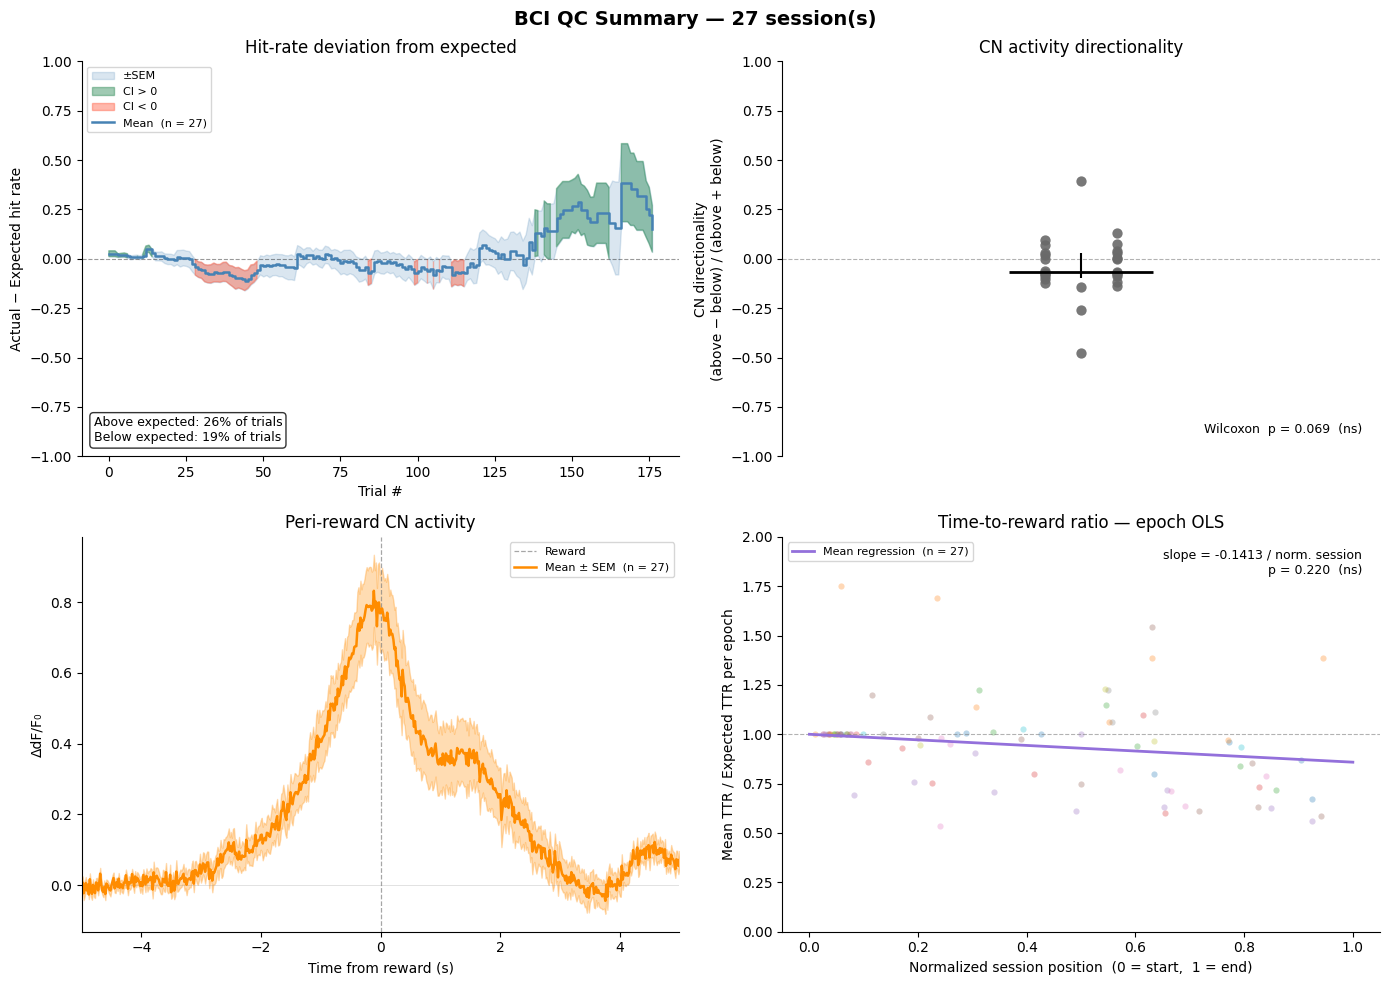


Saved → /results/figures/qc_summary.png


In [28]:
MIN_SESSIONS = 3   # minimum sessions required to plot at any trial index

if not session_records:
    print("No sessions loaded — nothing to plot.")
else:
    n_sess = len(session_records)
    np.random.seed(42)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"BCI QC Summary — {n_sess} session(s)",
                 fontsize=14, fontweight='bold')

    # ─────────────────────────────────────────────────────────────────────────
    # Panel 1 — Hit-rate deviation from expected
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[0, 0]
    mean_d, sem_d, n_d = pool_traces([s['hit_diff'] for s in session_records])
    # Contiguous cutoff: walk forward and stop at first trial below MIN_SESSIONS
    all_indices = np.arange(len(mean_d))
    cutoff_idx  = 0
    for idx in all_indices:
        if n_d[idx] >= MIN_SESSIONS:
            cutoff_idx = idx
        else:
            break

    x1    = np.arange(cutoff_idx + 1)
    mean_d = mean_d[:cutoff_idx + 1]
    sem_d  = sem_d[:cutoff_idx + 1]
    ci_lo  = mean_d - sem_d
    ci_hi  = mean_d + sem_d

    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.fill_between(x1, ci_lo, ci_hi,
                    alpha=0.2, color='steelblue', where=~np.isnan(ci_lo),
                    label='±SEM')
    ax.fill_between(x1, ci_lo, ci_hi,
                    alpha=0.45, color='seagreen',
                    where=(~np.isnan(ci_lo)) & (ci_lo > 0),
                    label='CI > 0')
    ax.fill_between(x1, ci_lo, ci_hi,
                    alpha=0.45, color='tomato',
                    where=(~np.isnan(ci_hi)) & (ci_hi < 0),
                    label='CI < 0')
    ax.step(x1, mean_d, where='post', color='steelblue', lw=1.8,
            label=f'Mean  (n = {n_sess})')
    has_ci   = ~np.isnan(sem_d)
    n_ci     = np.sum(has_ci)
    pct_up   = 100 * np.sum((ci_lo > 0) & has_ci) / n_ci if n_ci > 0 else 0
    pct_down = 100 * np.sum((ci_hi < 0) & has_ci) / n_ci if n_ci > 0 else 0
    ax.text(0.02, 0.03,
            f'Above expected: {pct_up:.0f}% of trials\nBelow expected: {pct_down:.0f}% of trials',
            transform=ax.transAxes, va='bottom', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_ylim(-1, 1)
    ax.set_xlabel('Trial #')
    ax.set_ylabel('Actual − Expected hit rate')
    ax.set_title('Hit-rate deviation from expected')
    ax.legend(fontsize=8, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Panel 2 — CN activity directionality
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[0, 1]
    metrics = np.array([s['cn_metric'] for s in session_records
                        if not np.isnan(s['cn_metric'])])

    # Beeswarm-style: sort values, place in tight column with overlap-aware offsets
    sorted_vals = np.sort(metrics)
    x_pos = np.zeros(len(sorted_vals))
    min_sep = 0.08   # minimum vertical separation in data units to share x=0
    for i in range(1, len(sorted_vals)):
        if abs(sorted_vals[i] - sorted_vals[i-1]) < min_sep:
            # alternate left/right of centre
            x_pos[i] = -x_pos[i-1] if x_pos[i-1] != 0 else 0.06
    ax.scatter(x_pos, sorted_vals, color='dimgray', s=55, alpha=0.9,
               zorder=3, linewidths=0)

    med      = np.median(metrics)
    q25, q75 = np.percentile(metrics, [25, 75])
    ax.plot([-0.12, 0.12], [med, med], '-', color='k', lw=2.0, zorder=5, solid_capstyle='butt')
    ax.vlines(0, q25, q75, lw=1.5, color='k', zorder=4)

    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
    p_cn = np.nan
    if len(metrics) >= 4:
        try:
            _, p_cn = stats.wilcoxon(metrics, alternative='two-sided')
        except Exception:
            _, p_cn = stats.ttest_1samp(metrics, 0)
    sig_cn = ('***' if p_cn < 0.001 else '**' if p_cn < 0.01
              else '*' if p_cn < 0.05 else 'ns')
    note = (f'Wilcoxon  p = {p_cn:.3f}  ({sig_cn})'
        if not np.isnan(p_cn) else f'N = {len(metrics)}')
    ax.text(0.97, 0.05, note, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9)

    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.set_ylim(-1, 1)
    ax.set_ylabel('CN directionality\n(above − below) / (above + below)')
    ax.set_title('CN activity directionality')
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

    # ─────────────────────────────────────────────────────────────────────────
    # Panel 3 — Peri-reward CN ΔdF/F₀
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[1, 0]
    valid_peris = [s['peri_trace'] for s in session_records
                   if s['peri_trace'] is not None]
    if valid_peris:
        mean_p, sem_p, _ = pool_traces(valid_peris)
        t_ax = np.linspace(PLOT_SEC[0], PLOT_SEC[1], len(mean_p))
        ax.axvline(0, color='gray', ls='--', lw=0.9, alpha=0.7, label='Reward')
        ax.axhline(0, color='gray', ls='-',  lw=0.4, alpha=0.4)
        ax.fill_between(t_ax, mean_p - sem_p, mean_p + sem_p,
                        alpha=0.3, color='darkorange', where=~np.isnan(sem_p))
        ax.plot(t_ax, mean_p, color='darkorange', lw=1.8,
                label=f'Mean ± SEM  (n = {len(valid_peris)})')
        ax.legend(fontsize=8)
        ax.set_xlim(PLOT_SEC)
    else:
        ax.text(0.5, 0.5, 'No valid peri-reward data',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    ax.set_xlabel('Time from reward (s)')
    ax.set_ylabel('ΔdF/F₀')
    ax.set_title('Peri-reward CN activity')
    ax.spines[['top', 'right']].set_visible(False)

    # ─────────────────────────────────────────────────────────────────────────
    # Panel 4 — TTR ratio, constrained regression
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[1, 1]
    axes[1, 1].set_ylim(0, 2)

    WEIGHT_BY_TRIALS = True

    # ── Per-session: epoch means + constrained linear slope ───────────────────────
    slopes_p           = []
    session_epoch_data = []

    for s in session_records:
        ratio   = s['ttr_ratio']
        sw      = list(s['switches']) + [len(ratio)]
        n_total = float(len(ratio))

        epoch_x, epoch_y = [], []
        for ei in range(len(sw) - 1):
            ep_s = int(sw[ei]);  ep_e = int(sw[ei + 1])
            mu   = float(np.nanmean(ratio[ep_s:ep_e]))
            if np.isnan(mu):
                continue
            epoch_x.append(((ep_s + ep_e) / 2.0) / n_total)
            epoch_y.append(mu)

        epoch_x = np.array(epoch_x);  epoch_y = np.array(epoch_y)
        session_epoch_data.append((epoch_x, epoch_y))

        if len(epoch_x) < 2:
            # Fallback: trial-level fit within the single epoch
            ep_s = int(sw[0]);  ep_e = int(sw[1]) if len(sw) > 1 else len(ratio)
            vals = ratio[ep_s:ep_e]
            xi_n = np.arange(len(vals), dtype=float) / max(len(vals) - 1, 1)
            hit  = ~np.isnan(vals)
            xi_h, yi_h = xi_n[hit], vals[hit]
            if len(xi_h) >= 4:
                denom = float(np.dot(xi_h, xi_h))
                slopes_p.append(float(np.dot(xi_h, yi_h - 1.0) / denom)
                                if denom > 0 else np.nan)
            else:
                slopes_p.append(np.nan)
            continue

        denom = float(np.dot(epoch_x, epoch_x))
        slopes_p.append(float(np.dot(epoch_x, epoch_y - 1.0) / denom)
                        if denom > 0 else np.nan)

    slopes_p   = np.array(slopes_p)
    n_trials_p = np.array([len(s['ttr_ratio']) for s in session_records], dtype=float)
    valid      = ~np.isnan(slopes_p)
    w          = n_trials_p[valid] ** 2 if WEIGHT_BY_TRIALS else np.ones(valid.sum())
    w         /= w.sum()
    mean_slope = float(np.dot(w, slopes_p[valid]))

    x_dense   = np.linspace(0, 1, 300)
    mean_line = 1.0 + mean_slope * x_dense

    # ── Faint epoch mean points per session ───────────────────────────────────────
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(session_records)))
    for (ex, ey), col in zip(session_epoch_data, colors):
        ax.scatter(ex, ey, color=col, alpha=0.3, s=20, zorder=1, linewidths=0)

    # ── Mean regression ───────────────────────────────────────────────────────────
    ax.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax.plot(x_dense, mean_line, color='mediumpurple', lw=2.0, zorder=3,
            label=f'Mean regression  (n = {n_sess})')

    # ── Slope test ────────────────────────────────────────────────────────────────
    p_slope      = np.nan
    valid_slopes = slopes_p[valid]
    if len(valid_slopes) >= 3:
        try:
            fn = stats.wilcoxon if len(valid_slopes) >= 5 else stats.ttest_1samp
            _, p_slope = (fn(valid_slopes, alternative='two-sided')
                        if len(valid_slopes) >= 5 else fn(valid_slopes, 0))
        except Exception:
            pass
    sig4 = ('***' if p_slope < 0.001 else '**' if p_slope < 0.01
            else '*' if p_slope < 0.05 else 'ns')
    txt  = (f'slope = {mean_slope:+.4f} / norm. session\n'
            f'p = {p_slope:.3f}  ({sig4})'
            if not np.isnan(p_slope)
            else f'slope = {mean_slope:+.4f} / norm. session')
    ax.text(0.97, 0.97, txt, transform=ax.transAxes,
            ha='right', va='top', fontsize=9)

    ax.set_xlabel('Normalized session position  (0 = start,  1 = end)')
    ax.set_ylabel('Mean TTR / Expected TTR per epoch')
    ax.set_title('Time-to-reward ratio — epoch OLS')
    ax.legend(fontsize=8, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    
    # ── Save ──────────────────────────────────────────────────────────────────
    plt.tight_layout()
    out = Path("/results/figures/qc_summary.png")
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved → {out}")


In [29]:
# # ── Figure 2: peri-reward CN activity per trial ───────────────────────────────
# MIN_SESSIONS = 3   # stop plotting when fewer than this many sessions contribute

# pt_traces = [s['peri_trial_norm'] for s in session_records]
# mean_pt, sem_pt, n_valid_pt = pool_traces(pt_traces)

# # Cutoff: last trial index where n_valid >= MIN_SESSIONS
# valid_mask = n_valid_pt >= MIN_SESSIONS
# if not valid_mask.any():
#     print("No trials with enough sessions to plot.")
# else:
#     cutoff = int(np.where(valid_mask)[0][-1]) + 1
#     x   = np.arange(cutoff)
#     mu  = mean_pt[:cutoff]
#     sem = sem_pt[:cutoff]

#     fig2, ax2 = plt.subplots(figsize=(10, 4))
#     fig2.suptitle(f"CN peri-reward activity per trial - {len(session_records)} sessions",
#                   fontsize=12, fontweight='bold')

#     ax2.fill_between(x, mu - sem, mu + sem,
#                      alpha=0.3, color='steelblue', where=~np.isnan(sem))
#     ax2.plot(x, mu, color='steelblue', lw=1.8,
#              label=f'Mean ± SEM  (cutoff at trial {cutoff}, '
#                    f'n ≥ {MIN_SESSIONS})')

#     ax2.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)

#     ax2.set_xlabel('Trial #')
#     ax2.set_ylabel('Peri-reward ΔdF/F\n(normalized to trials 4–13)')
#     ax2.legend(fontsize=8, loc='upper right')
#     ax2.spines[['top', 'right']].set_visible(False)
#     plt.tight_layout()

#     out2 = Path("/results/figures/qc_peri_trial.png")
#     out2.parent.mkdir(parents=True, exist_ok=True)
#     fig2.savefig(out2, dpi=150, bbox_inches='tight')
#     plt.show()
#     print(f"Saved → {out2}")
#     print(f"Plotted trials 0–{cutoff - 1}  |  "
#           f"sessions per trial: min={n_valid_pt[:cutoff].min():.0f}  "
#           f"max={n_valid_pt[:cutoff].max():.0f}")

<ipython-input-25-ed7d21ce9eb2>:18: RuntimeWarning: Mean of empty slice
  mean  = np.nanmean(mat, axis=0)


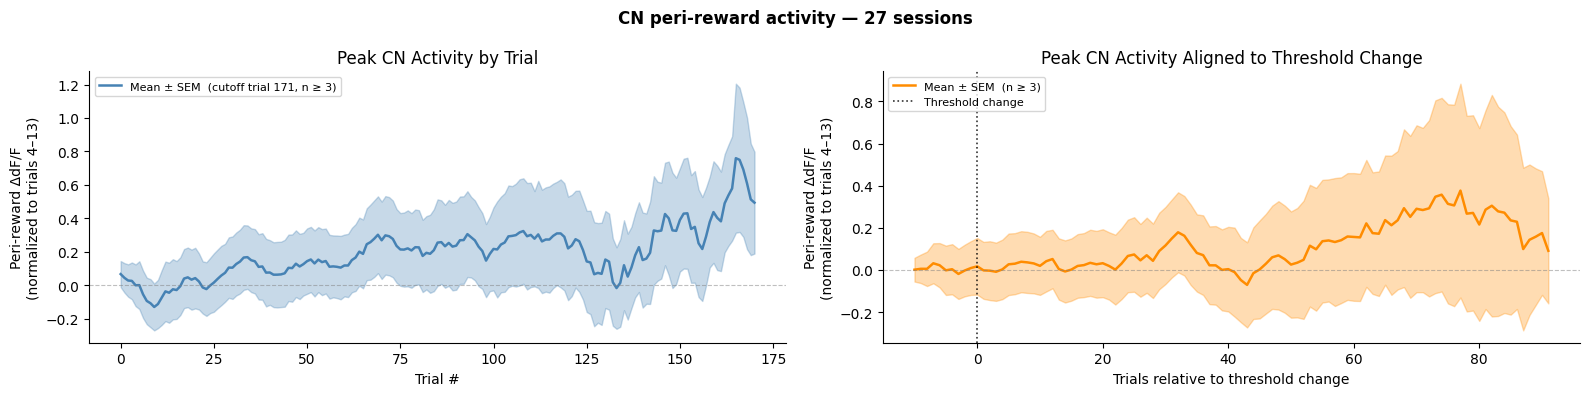

Saved → /results/figures/qc_peri_trial.png
Panel 2a: trials 0–170


In [30]:
# ── Figure 2: peri-reward CN activity ─────────────────────────────────────────
MIN_SESSIONS = 3

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 4))
fig2.suptitle(f"CN peri-reward activity — {len(session_records)} sessions",
              fontsize=12, fontweight='bold')

# ── Panel 2a: aligned to trial # ──────────────────────────────────────────────
ax = axes2[0]
pt_traces            = [s['peri_trial_norm'] for s in session_records]
mean_pt, sem_pt, n_valid_pt = pool_traces(pt_traces)

valid_mask = n_valid_pt >= MIN_SESSIONS
if valid_mask.any():
    cutoff = int(np.where(valid_mask)[0][-1]) + 1
    x      = np.arange(cutoff)
    mu     = mean_pt[:cutoff]
    mu_smooth = np.convolve(mu, np.ones(CN_SMOOTH) / CN_SMOOTH, mode='same')
    sem    = sem_pt[:cutoff]
    sem_smooth = np.convolve(np.where(np.isnan(sem), 0, sem),
                             np.ones(CN_SMOOTH) / CN_SMOOTH, mode='same')

    ax.fill_between(x, mu_smooth - sem_smooth, mu_smooth + sem_smooth,
                    alpha=0.3, color='steelblue', where=~np.isnan(sem_smooth))
    ax.plot(x, mu_smooth, color='steelblue', lw=1.8,
            label=f'Mean ± SEM  (cutoff trial {cutoff}, n ≥ {MIN_SESSIONS})')
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_xlabel('Trial #')
    ax.set_ylabel('Peri-reward ΔdF/F\n(normalized to trials 4–13)')
    ax.set_title('Peak CN Activity by Trial')
    ax.legend(fontsize=8, loc='upper left')
else:
    ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
            transform=ax.transAxes)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2b: aligned to threshold change (negative = before, 0 = change) ─────
ax     = axes2[1]
N_PRE  = 10   # trials to show before each threshold change

session_relative_means = []
for s in session_records:
    pt = s['peri_trial_norm']
    sw = list(s['switches']) + [len(pt)]

    epoch_traces = []
    for i in range(len(sw) - 1):
        ep_s = int(sw[i]);  ep_e = int(sw[i + 1])
        
        # Pre-change: right-align into a fixed N_PRE window
        # so index N_PRE-1 is always the trial immediately before the change
        pre      = np.full(N_PRE, np.nan)
        pre_vals = pt[max(0, ep_s - N_PRE):ep_s]
        if len(pre_vals) > 0:
            pre[-len(pre_vals):] = pre_vals

        post = pt[ep_s:ep_e]

        # ── Re-normalize to mean of the N_PRE trials before this threshold change ─
        baseline_epoch = float(np.nanmean(pre_vals)) if len(pre_vals) > 0 else np.nan
        pre_renorm     = pre  - baseline_epoch
        post_renorm    = post - baseline_epoch

        epoch_traces.append(np.concatenate([pre_renorm, post_renorm]))

    if not epoch_traces:
        session_relative_means.append(np.array([np.nan]))
        continue

    ep_mean, _, _ = pool_traces(epoch_traces)
    session_relative_means.append(ep_mean)

mean_rel, sem_rel, n_valid_rel = pool_traces(session_relative_means)

# x=0 sits at array index N_PRE
x_rel = np.arange(len(mean_rel)) - N_PRE

valid_mask_rel = n_valid_rel >= MIN_SESSIONS
if valid_mask_rel.any():
        # Find cutoff as first index where n_valid drops below MIN_SESSIONS
    # rather than taking all valid indices (which can include sparse late points)
    post_mask = (x_rel >= 0) & valid_mask_rel
    if post_mask.any():
        # Walk forward from 0 and stop at first gap
        post_indices = np.where(x_rel >= 0)[0]
        cutoff_idx   = post_indices[0]   # index in the array where x=0 starts
        for idx in post_indices:
            if n_valid_rel[idx] >= MIN_SESSIONS:
                cutoff_idx = idx
            else:
                break   # stop at first trial below threshold
        keep = np.arange(0, cutoff_idx + 1)   # all indices from start through cutoff
    else:
        keep = np.array([], dtype=int)
    x_plot     = x_rel[keep]
    mu_plot    = mean_rel[keep]
    sem_plot   = sem_rel[keep]
    mu_smooth_rel  = np.convolve(mu_plot,  np.ones(CN_SMOOTH) / CN_SMOOTH, mode='same')
    sem_smooth_rel = np.convolve(np.where(np.isnan(sem_plot), 0, sem_plot),
                                 np.ones(CN_SMOOTH) / CN_SMOOTH, mode='same')

    ax.fill_between(x_plot, mu_smooth_rel - sem_smooth_rel,
                    mu_smooth_rel + sem_smooth_rel,
                    alpha=0.3, color='darkorange', where=~np.isnan(sem_smooth_rel))
    ax.plot(x_plot, mu_smooth_rel, color='darkorange', lw=1.8,
            label=f'Mean ± SEM  (n ≥ {MIN_SESSIONS})')
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.axvline(0, color='k', ls=':', lw=1.2, alpha=0.8,
               label='Threshold change')
    ax.set_xlabel('Trials relative to threshold change')
    ax.set_ylabel('Peri-reward ΔdF/F\n(normalized to trials 4–13)')
    ax.set_title('Peak CN Activity Aligned to Threshold Change')
    ax.legend(fontsize=8, loc='upper left')
else:
    ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
            transform=ax.transAxes)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out2 = Path("/results/figures/qc_peri_trial.png")
out2.parent.mkdir(parents=True, exist_ok=True)
fig2.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out2}")
print(f"Panel 2a: trials 0–{cutoff-1 if valid_mask.any() else 'N/A'}")
# print(f"Panel 2b: up to +{cutoff_rel-1 if valid_mask_rel.any() else 'N/A'} "
#       f"trials post-change")

In [31]:
# # ── Panel 4 diagnostic: toggle anchored vs free regression + slope p-value ────
# ANCHOR_AT_ONE = False  # True = constrained through (0,1); False = free OLS

# slopes_plot     = []
# intercepts_plot = []
# fitteds_plot    = []

# for s in session_records:
#     hit_mask = ~np.isnan(s['ttr_ratio'])
#     xi = np.arange(len(s['ttr_ratio']))[hit_mask].astype(float)
#     yi = s['ttr_ratio'][hit_mask]
#     if ANCHOR_AT_ONE:
#         slopes_plot.append(s['slope'])
#         intercepts_plot.append(1.0)
#         fitteds_plot.append(s['ttr_fitted'])
#     elif len(xi) >= 2:
#         res = stats.linregress(xi, yi)
#         slopes_plot.append(res.slope)
#         intercepts_plot.append(res.intercept)
#         fitteds_plot.append(res.intercept + res.slope
#                             * np.arange(len(s['ttr_ratio']), dtype=float))
#     else:
#         slopes_plot.append(np.nan)
#         intercepts_plot.append(np.nan)
#         fitteds_plot.append(np.full(len(s['ttr_ratio']), np.nan))

# slopes_plot     = np.array(slopes_plot)
# intercepts_plot = np.array(intercepts_plot)

# mean_slope     = float(np.nanmean(slopes_plot))
# mean_intercept = float(np.nanmean(intercepts_plot))
# valid_slopes   = slopes_plot[~np.isnan(slopes_plot)]
# _, p_slope     = (stats.ttest_1samp(valid_slopes, 0)
#                   if len(valid_slopes) >= 2 else (np.nan, np.nan))
# sig = '***' if p_slope < 0.001 else '**' if p_slope < 0.01 else '*' if p_slope < 0.05 else 'ns'

# x_max  = max(len(f) for f in fitteds_plot)
# x4     = np.arange(x_max, dtype=float)
# colors = plt.cm.tab10(np.linspace(0, 0.9, len(session_records)))

# fig, ax = plt.subplots(figsize=(10, 5))
# anchor_str = 'anchored Y=1' if ANCHOR_AT_ONE else 'free OLS'

# for s, fitted, col in zip(session_records, fitteds_plot, colors):
#     hit_mask = ~np.isnan(s['ttr_ratio'])
#     xi = np.arange(len(s['ttr_ratio']))[hit_mask]
#     ax.scatter(xi, s['ttr_ratio'][hit_mask],
#                color=col, alpha=0.35, s=10, zorder=1, linewidths=0)
#     ax.plot(np.arange(len(fitted)), fitted,
#             color=col, lw=1.5, alpha=0.8, label=s['label'], zorder=2)

# mean_line = mean_intercept + mean_slope * x4
# ax.plot(x4, mean_line, color='k', lw=2.5, ls='--', zorder=3,
#         label=f'Mean ({anchor_str})')

# ax.axhline(1.0, color='gray', ls=':', lw=0.8, alpha=0.6)
# ax.text(0.97, 0.97,
#         f'mean slope = {mean_slope:+.5f} / trial\np = {p_slope:.3f}  ({sig})',
#         transform=ax.transAxes, ha='right', va='top', fontsize=9)

# ax.set_xlabel('Trial #')
# ax.set_ylabel('TTR / Expected TTR')
# ax.set_title(f'Panel 4 diagnostic — {anchor_str}')
# ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
# ax.spines[['top', 'right']].set_visible(False)
# plt.tight_layout()
# plt.show()

In [32]:
# # ── Panel 4 diagnostic: early-trial baseline normalization ────────────────────
# ANCHOR_AT_ONE = True   # True = constrained through (0,1); False = free OLS
# N_BASELINE    = 10     # early hit trials used to define each session's baseline

# slopes_plot      = []
# intercepts_plot  = []
# fitteds_plot     = []
# norm_ratio_list  = []

# for s in session_records:
#     hit_mask    = ~np.isnan(s['ttr_ratio'])
#     hit_indices = np.where(hit_mask)[0]

#     if len(hit_indices) < N_BASELINE:
#         print(f"  {s['label']}: only {len(hit_indices)} hits — skipping")
#         slopes_plot.append(np.nan)
#         intercepts_plot.append(np.nan)
#         fitteds_plot.append(np.full(len(s['ttr_ratio']), np.nan))
#         norm_ratio_list.append(np.full(len(s['ttr_ratio']), np.nan))
#         continue

#     # Normalize by mean TTR of first N_BASELINE hit trials
#     # First N hits will average to 1.0 by construction → anchor is meaningful
#     baseline   = float(np.mean(s['ttr_ratio'][hit_indices[:N_BASELINE]]))
#     norm_ratio = s['ttr_ratio'] / baseline          # NaN for misses preserved
#     norm_ratio_list.append(norm_ratio)

#     xi = hit_indices.astype(float)
#     yi = norm_ratio[hit_mask]

#     if ANCHOR_AT_ONE:
#         y_shifted = yi - 1.0
#         denom     = float(np.dot(xi, xi))
#         slope     = float(np.dot(xi, y_shifted)) / denom if denom > 0 else 0.0
#         intercept = 1.0
#     else:
#         res       = stats.linregress(xi, yi)
#         slope     = res.slope
#         intercept = res.intercept

#     fitted = intercept + slope * np.arange(len(s['ttr_ratio']), dtype=float)
#     slopes_plot.append(slope)
#     intercepts_plot.append(intercept)
#     fitteds_plot.append(fitted)

# slopes_plot     = np.array(slopes_plot)
# intercepts_plot = np.array(intercepts_plot)
# valid_slopes    = slopes_plot[~np.isnan(slopes_plot)]
# mean_slope      = float(np.nanmean(slopes_plot))
# mean_intercept  = float(np.nanmean(intercepts_plot))

# _, p_slope = (stats.ttest_1samp(valid_slopes, 0)
#               if len(valid_slopes) >= 2 else (np.nan, np.nan))
# sig = ('***' if p_slope < 0.001 else '**' if p_slope < 0.01
#        else '*' if p_slope < 0.05 else 'ns')

# x_max  = max(len(f) for f in fitteds_plot)
# x4     = np.arange(x_max, dtype=float)
# colors = plt.cm.tab10(np.linspace(0, 0.9, len(session_records)))

# fig, ax = plt.subplots(figsize=(10, 5))
# anchor_str = 'anchored Y=1' if ANCHOR_AT_ONE else 'free OLS'

# for s, norm_ratio, fitted, col in zip(session_records, norm_ratio_list,
#                                        fitteds_plot, colors):
#     hit_mask = ~np.isnan(norm_ratio)
#     xi       = np.arange(len(norm_ratio))[hit_mask]
#     ax.scatter(xi, norm_ratio[hit_mask],
#                color=col, alpha=0.35, s=10, zorder=1, linewidths=0)
#     ax.plot(np.arange(len(fitted)), fitted,
#             color=col, lw=1.5, alpha=0.8, label=s['label'], zorder=2)

# ax.plot(x4, mean_intercept + mean_slope * x4,
#         color='k', lw=2.5, ls='--', zorder=3, label=f'Mean ({anchor_str})')
# ax.axhline(1.0, color='gray', ls=':', lw=0.8, alpha=0.6, label='Baseline')
# ax.text(0.97, 0.97,
#         f'mean slope = {mean_slope:+.5f} / trial\np = {p_slope:.3f}  ({sig})',
#         transform=ax.transAxes, ha='right', va='top', fontsize=9)

# ax.set_xlabel('Trial #')
# ax.set_ylabel(f'TTR / Mean first-{N_BASELINE}-hit TTR')
# ax.set_title(f'Panel 4 diagnostic — early-trial baseline normalization ({anchor_str})')
# ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
# ax.spines[['top', 'right']].set_visible(False)
# plt.tight_layout()
# plt.show()

In [33]:
# # ── CN metric debug: step-by-step for one session ─────────────────────────────
# DEBUG_SESSION_IDX = 0   # change to inspect a different session

# s        = session_records[DEBUG_SESSION_IDX]
# trace = np.asarray(s['cn_act'], dtype=float)[3:]
# x_raw = np.arange(3, 3 + len(trace))   # keep x-axis aligned to real trial numbers

# # Step 1: smooth
# nans = np.isnan(trace)
# if nans.any():
#     x_all = np.arange(len(trace))
#     trace = np.interp(x_all, x_all[~nans], trace[~nans])
# smoothed = np.convolve(trace, np.ones(CN_SMOOTH) / CN_SMOOTH, mode='valid')
# offset   = (CN_SMOOTH - 1) // 2
# x_sm     = np.arange(offset, offset + len(smoothed))

# # Step 2: derivative
# deriv    = np.diff(smoothed)
# x_deriv  = x_sm[:-1] + 0.5

# # Step 3: metric
# above  = deriv[deriv > 0].sum()
# below  = np.abs(deriv[deriv < 0]).sum()
# total  = above + below
# metric = (above - below) / total if total > 0 else 0.0

# fig, axes_d = plt.subplots(2, 1, figsize=(11, 7))
# fig.suptitle(
#     f"CN metric debug — {s['label']}  |  CN_SMOOTH = {CN_SMOOTH}  |  "
#     f"metric = {metric:+.3f}",
#     fontsize=12, fontweight='bold')

# # ── Top: raw + smoothed trace ─────────────────────────────────────────────────
# ax = axes_d[0]
# ax.plot(x_raw, trace,   color='lightgray', lw=0.8, label='Raw')
# ax.plot(x_sm,  smoothed, color='steelblue', lw=1.8,
#         label=f'Smoothed  (window = {CN_SMOOTH})')
# ax.set_ylabel('CN activity (mean dF/F per trial)')
# ax.set_title('Step 1 — smooth the trace')
# ax.legend(fontsize=9)
# ax.spines[['top', 'right']].set_visible(False)

# # ── Bottom: derivative + shaded integrals ─────────────────────────────────────
# ax = axes_d[1]
# ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
# ax.plot(x_deriv, deriv, color='k', lw=1.0)
# ax.fill_between(x_deriv, deriv, 0, where=(deriv > 0),
#                 color='seagreen', alpha=0.5,
#                 label=f'Above 0  (Σ = {above:.3f})')
# ax.fill_between(x_deriv, deriv, 0, where=(deriv < 0),
#                 color='tomato',  alpha=0.5,
#                 label=f'Below 0  (Σ = {below:.3f})')
# ax.set_xlabel('Trial #')
# ax.set_ylabel('Δ CN activity / trial')
# ax.set_title(
#     f'Step 2 — derivative  →  '
#     f'(above − below) / (above + below) = '
#     f'({above:.3f} − {below:.3f}) / {total:.3f} = {metric:+.3f}')
# ax.legend(fontsize=9)
# ax.spines[['top', 'right']].set_visible(False)

# plt.tight_layout()
# plt.show()

In [34]:
# # ── Panel 4 diagnostic: normalized epoch fit, power law + linear (both anchored) ─
# from scipy.optimize import curve_fit

# def power_law_norm(x, b):
#     """(1 + x)^b — anchored at Y=1 when x=0, for any b."""
#     return (1.0 + x) ** b

# def linear_anchored(x, slope):
#     """1 + slope·x — anchored at Y=1 when x=0."""
#     return 1.0 + slope * x

# colors  = plt.cm.tab10(np.linspace(0, 0.9, len(session_records)))
# x_dense = np.linspace(0, 1, 300)
# session_fits = []

# fig, ax = plt.subplots(figsize=(11, 5))

# for s, col in zip(session_records, colors):
#     ratio   = s['ttr_ratio']
#     sw      = list(s['switches']) + [len(ratio)]
#     n_total = float(len(ratio))
#     fits    = dict(label=s['label'], n_epochs=len(sw)-1,
#                    lin=np.nan, pow=np.nan, fallback=False)

#     epoch_x, epoch_y, epoch_n = [], [], []
#     for ei in range(len(sw) - 1):
#         ep_s = int(sw[ei]);  ep_e = int(sw[ei + 1])
#         vals = ratio[ep_s:ep_e]
#         mu   = float(np.nanmean(vals))
#         if np.isnan(mu):
#             continue
#         x_norm = ((ep_s + ep_e) / 2.0) / n_total
#         epoch_x.append(x_norm)
#         epoch_y.append(mu)
#         epoch_n.append(ep_e - ep_s)

#     epoch_x = np.array(epoch_x);  epoch_y = np.array(epoch_y)
#     epoch_n = np.array(epoch_n, dtype=float)

#     # Scatter: size proportional to trial count
#     ax.scatter(epoch_x, epoch_y, color=col, alpha=0.8, zorder=3,
#                s=epoch_n * 3, linewidths=0.5, edgecolors='white')
#     ax.plot(epoch_x, epoch_y, color=col, alpha=0.35, lw=1.0, zorder=2)

#     if len(epoch_x) < 2:
#         # ── Fallback: trial-level fit within the single epoch ─────────────────
#         ep_s = int(sw[0]);  ep_e = int(sw[1]) if len(sw) > 1 else len(ratio)
#         vals = ratio[ep_s:ep_e]
#         xi   = np.arange(len(vals), dtype=float)
#         xi_n = xi / max(xi[-1], 1.0)           # normalize to [0, 1]
#         hit_mask  = ~np.isnan(vals)
#         xi_n_hit  = xi_n[hit_mask]
#         yi_hit    = vals[hit_mask]

#         if len(xi_n_hit) >= 4:
#             fits['fallback'] = True
#             # Plot raw trial points (small, dotted style)
#             ax.scatter(xi_n_hit, yi_hit, color=col, alpha=0.3,
#                        s=6, zorder=2, linewidths=0, marker='.')
#             # Constrained linear fallback
#             y_shifted = yi_hit - 1.0
#             denom     = float(np.dot(xi_n_hit, xi_n_hit))
#             if denom > 0:
#                 fits['lin'] = float(np.dot(xi_n_hit, y_shifted) / denom)
#             # Power law fallback
#             try:
#                 popt, _ = curve_fit(power_law_norm, xi_n_hit, yi_hit,
#                                     p0=[-0.3], maxfev=10000)
#                 fits['pow'] = float(popt[0])
#                 ax.plot(x_dense, power_law_norm(x_dense, fits['pow']),
#                         color=col, lw=0.8, alpha=0.25, ls=':', zorder=2)
#             except Exception as e:
#                 print(f"  Trial-level fallback failed {s['label']}: {e}")

#         session_fits.append(fits)
#         continue

#     # ── Constrained linear — slope-only OLS on (y - 1) ───────────────────────
#     y_shifted = epoch_y - 1.0
#     denom     = float(np.dot(epoch_x, epoch_x))
#     if denom > 0:
#         fits['lin'] = float(np.dot(epoch_x, y_shifted) / denom)

#     # ── Power law — single free parameter b ───────────────────────────────────
#     try:
#         popt, _ = curve_fit(power_law_norm, epoch_x, epoch_y,
#                             p0=[-0.3], maxfev=10000)
#         fits['pow'] = float(popt[0])
#     except Exception as e:
#         print(f"  Power law failed {s['label']}: {e}")

#     session_fits.append(fits)

# # ── Individual session fits (faint, solid=epoch-level, dotted=trial fallback) ─
# for f, col in zip(session_fits, colors):
#     if not np.isnan(f['pow']):
#         ls = ':' if f['fallback'] else '-'
#         ax.plot(x_dense, power_law_norm(x_dense, f['pow']),
#                 color=col, lw=0.8, alpha=0.25, ls=ls, zorder=2)

# # ── Mean fits ─────────────────────────────────────────────────────────────────
# pow_bs     = np.array([f['pow'] for f in session_fits if not np.isnan(f['pow'])])
# lin_slopes = np.array([f['lin'] for f in session_fits if not np.isnan(f['lin'])])

# if len(pow_bs) > 0:
#     mean_b = float(np.mean(pow_bs))
#     ax.plot(x_dense, power_law_norm(x_dense, mean_b),
#             color='seagreen', lw=2.5, zorder=4,
#             label=f'Power law  (1+x)^b   mean b = {mean_b:.3f}')

# if len(lin_slopes) > 0:
#     mean_slope = float(np.mean(lin_slopes))
#     ax.plot(x_dense, linear_anchored(x_dense, mean_slope),
#             color='steelblue', lw=2.5, ls='--', zorder=4,
#             label=f'Linear  1+slope·x   mean slope = {mean_slope:.3f}')

# ax.axhline(1.0, color='gray', ls=':', lw=0.8, alpha=0.6, label='Y = 1  (on target)')
# ax.set_xlim(-0.02, 1.05)
# ax.set_xlabel('Normalized session position  (0 = start,  1 = end)')
# ax.set_ylabel('Mean TTR / Expected TTR per epoch')
# ax.set_title('Panel 4 diagnostic — normalized epoch fit  (anchor Y=1)')
# ax.legend(fontsize=9, loc='upper right')
# ax.spines[['top', 'right']].set_visible(False)
# plt.tight_layout()
# plt.show()

# # ── Parameter table ───────────────────────────────────────────────────────────
# print(f"\n{'Session':<25} {'Epochs':>6} {'Lin slope':>10} {'Pow b':>10}  Interpretation")
# for f in session_fits:
#     ls   = f"{f['lin']:>10.4f}" if not np.isnan(f['lin']) else f"{'nan':>10}"
#     ps   = f"{f['pow']:>10.4f}" if not np.isnan(f['pow']) else f"{'nan':>10}"
#     flag = '*' if f['fallback'] else ' '
#     if np.isnan(f['pow']):
#         interp = 'too few data'
#     elif f['pow'] < -0.1:
#         interp = 'clear learning'
#     elif f['pow'] < 0:
#         interp = 'mild learning'
#     elif f['pow'] < 0.1:
#         interp = 'flat'
#     else:
#         interp = 'regression'
#     print(f"{f['label']:<25} {f['n_epochs']:>6} {ls} {ps}  {interp}{flag}")

# print("\n* = trial-level fallback (single epoch; b estimated within-epoch)")

# # ── Statistical tests ─────────────────────────────────────────────────────────
# print()
# for label, vals in [('Power law b', pow_bs), ('Linear slope', lin_slopes)]:
#     if len(vals) >= 3:
#         fn = stats.wilcoxon if len(vals) >= 5 else stats.ttest_1samp
#         _, p = (fn(vals, alternative='two-sided') if len(vals) >= 5
#                 else fn(vals, 0))
#         sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
#         print(f"{label:<14}  n={len(vals)}  mean={np.mean(vals):+.4f}"
#               f"  p={p:.3f} ({sig})")

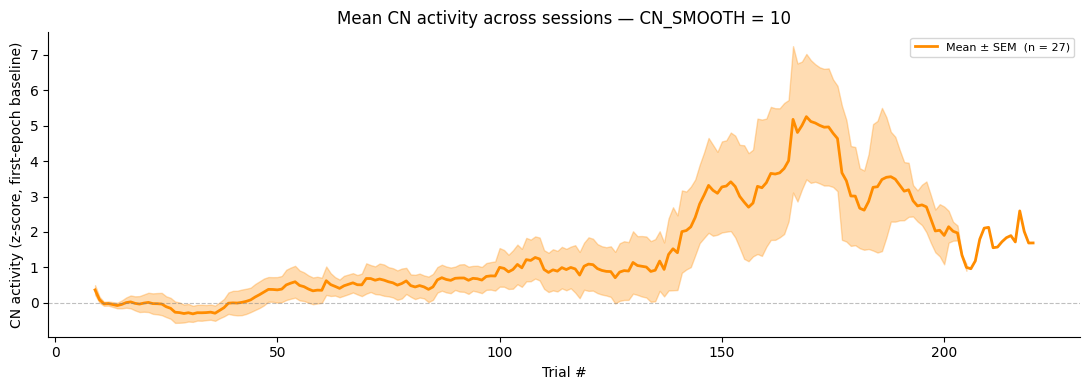

In [35]:
# ── Debug: mean CN activity across sessions (z-scored, smoothed) ──────────────
w = CN_SMOOTH
cn_sm_traces = []

for s in session_records:
    raw  = np.asarray(s['cn_act_z'], dtype=float)
    nans = np.isnan(raw)
    if nans.any() and not nans.all():
        xi  = np.arange(len(raw))
        raw = np.interp(xi, xi[~nans], raw[~nans])
    cn_sm_traces.append(np.convolve(raw, np.ones(w) / w, mode='valid'))

mean_cn, sem_cn, _ = pool_traces(cn_sm_traces)
x = np.arange(w - 1, w - 1 + len(mean_cn))

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(x, mean_cn - sem_cn, mean_cn + sem_cn,
                alpha=0.3, color='darkorange', where=~np.isnan(sem_cn))
ax.plot(x, mean_cn, color='darkorange', lw=2.0,
        label=f'Mean ± SEM  (n = {len(cn_sm_traces)})')
ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Trial #')
ax.set_ylabel('CN activity (z-score, first-epoch baseline)')
ax.set_title(f'Mean CN activity across sessions — CN_SMOOTH = {CN_SMOOTH}')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

  849680  2026-06-22: 93 trials
  849680  2026-06-23: 73 trials
  849680  2026-06-24: 101 trials
  857094  2026-06-02: 118 trials
  857094  2026-06-03: 105 trials
  857094  2026-06-04: 113 trials
  857094  2026-06-05: 107 trials
  857094  2026-06-09: 128 trials
  857094  2026-06-10: 99 trials
  857094  2026-06-11: 129 trials
  857094  2026-06-15: 68 trials
  857094  2026-06-16: 95 trials
  857094  2026-06-17: 185 trials
  857094  2026-06-18: 76 trials
  857094  2026-06-22: 78 trials
  857094  2026-06-24: 161 trials
  857095  2026-06-01: 49 trials
  857095  2026-06-03: 49 trials
  857095  2026-06-04: 72 trials
  857095  2026-06-05: 194 trials
  857095  2026-06-09: 67 trials
  857095  2026-06-10: 74 trials
  857095  2026-06-11: 93 trials
  857095  2026-06-15: 45 trials
  857095  2026-06-16: 81 trials
  857095  2026-06-17: 56 trials
  857095  2026-06-18: 36 trials


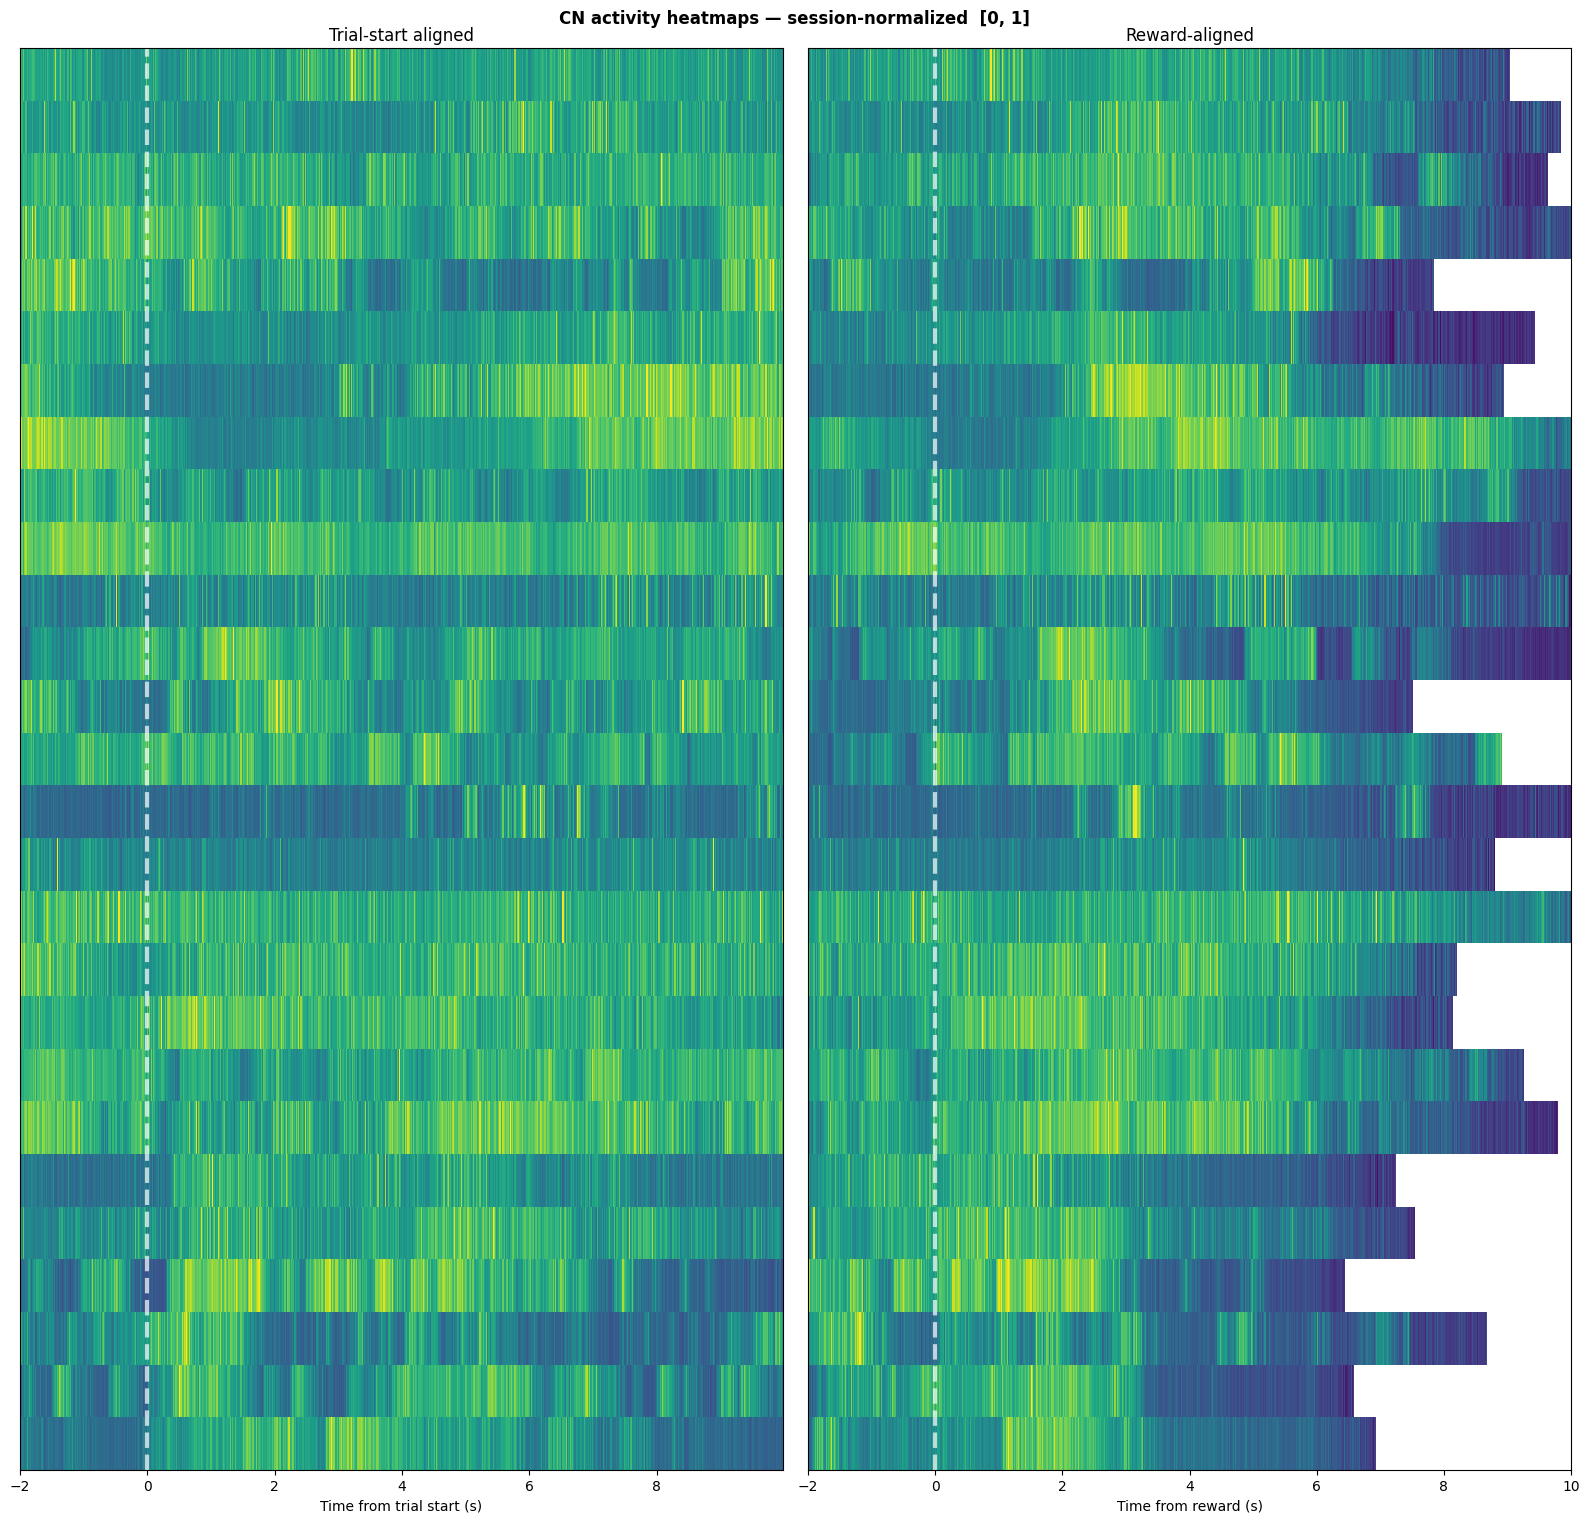

Saved → /results/figures/qc_heatmaps.png


In [36]:
# ── Figure 3: CN activity heatmaps ────────────────────────────────────────────
HEATMAP_PRE  = 2.0    # seconds before reward
HEATMAP_POST = 10.0   # seconds after reward

n_sess  = len(session_records)
fs_ref  = session_records[0]['fs']
hp_disp = int(HEATMAP_PRE  * fs_ref)
hq_disp = int(HEATMAP_POST * fs_ref)
p_len   = hp_disp + hq_disp

# ── Trial-start-aligned matrix ─────────────────────────────────────────────────
t_len      = max(len(s['cn_heat_trial']) for s in session_records)
heat_trial = np.full((n_sess, t_len), np.nan)
for i, s in enumerate(session_records):
    n = len(s['cn_heat_trial'])
    heat_trial[i, :n] = s['cn_heat_trial']

# ── Reward-aligned matrix ──────────────────────────────────────────────────────
heat_peri = np.full((n_sess, p_len), np.nan)
for i, s in enumerate(session_records):
    F_cn_s = s['F_norm_cn']        # (700, n_trials)
    rt_s   = s['rew_trial_sec']    # (n_trials,) seconds within trial
    n_t    = F_cn_s.shape[0]
    hp     = int(HEATMAP_PRE  * s['fs'])
    hq     = int(HEATMAP_POST * s['fs'])
    trials = []

    for i_tr in range(F_cn_s.shape[1]):
        if np.isnan(rt_s[i_tr]):
            continue
        rf     = int(rt_s[i_tr] / s['dt_si'])
        ws_raw = rf - hp
        we_raw = rf + hq
        ws     = max(0, ws_raw)
        we     = min(n_t, we_raw)
        if ws >= we:
            continue
        seg            = np.full(p_len, np.nan)
        out_start      = ws - ws_raw    # shift rightward when pre-reward clipped
        out_end        = out_start + (we - ws)
        seg[out_start:out_end] = F_cn_s[ws:we, i_tr]
        trials.append(seg)

    if trials:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            heat_peri[i, :] = np.nanmax(trials, axis=0)
        print(f"  {s['label']}: {len(trials)} trials")
    else:
        print(f"  {s['label']}: no valid trials")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(16, max(4, n_sess * 0.5 + 2)))
fig3.suptitle('CN activity heatmaps — session-normalized  [0, 1]',
              fontsize=12, fontweight='bold')

t_ax  = session_records[0]['t_bci']
t_pre = np.linspace(-HEATMAP_PRE, HEATMAP_POST, p_len)

ax = axes3[0]
ax.imshow(heat_trial, aspect='auto', interpolation='nearest',
          vmin=0, vmax=1, cmap='viridis',
          extent=[t_ax[0], t_ax[-1], n_sess - 0.5, -0.5])
ax.axvline(0, color='w', lw=3.0, ls='--', alpha=0.7)
ax.set_xlabel('Time from trial start (s)')
ax.set_title('Trial-start aligned')
ax.set_yticks([])

ax = axes3[1]
ax.imshow(heat_peri, aspect='auto', interpolation='nearest',
          vmin=0, vmax=1, cmap='viridis',
          extent=[t_pre[0], t_pre[-1], n_sess - 0.5, -0.5])
ax.axvline(0, color='w', lw=3.0, ls='--', alpha=0.7)
ax.set_xlabel('Time from reward (s)')
ax.set_title('Reward-aligned')
ax.set_yticks([])

plt.tight_layout()
out3 = Path("/results/figures/qc_heatmaps.png")
out3.parent.mkdir(parents=True, exist_ok=True)
fig3.savefig(out3, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out3}")

  849680  2026-06-22: best window trials 41–60  net rise=+1.1760  slope=+0.01423/trial
  849680  2026-06-23: best window trials 48–67  net rise=+0.7568  slope=+0.00264/trial
  849680  2026-06-24: best window trials 52–71  net rise=+2.1279  slope=+0.05035/trial
  857094  2026-06-02: best window trials 28–47  net rise=+1.2647  slope=+0.00451/trial
  857094  2026-06-03: best window trials 73–92  net rise=+1.3993  slope=+0.02250/trial
  857094  2026-06-04: best window trials 146–165  net rise=+1.7841  slope=+0.00955/trial
  857094  2026-06-05: best window trials 17–36  net rise=+0.5680  slope=+0.01247/trial
  857094  2026-06-09: best window trials 63–82  net rise=+1.1544  slope=+0.03215/trial
  857094  2026-06-10: best window trials 37–56  net rise=+1.7105  slope=+0.00104/trial
  857094  2026-06-11: best window trials 30–49  net rise=+1.7799  slope=+0.03952/trial
  857094  2026-06-15: best window trials 29–48  net rise=+0.8032  slope=+0.00127/trial
  857094  2026-06-16: best window trials 

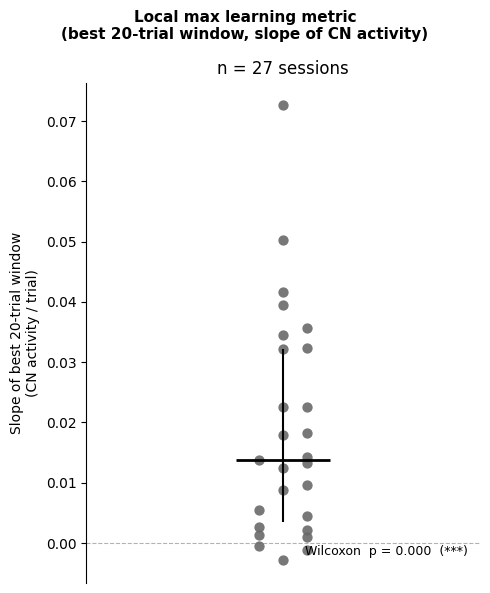


Saved → /results/figures/qc_local_learning.png
Median slope: +0.01383/trial  |  IQR: [+0.00357, +0.03225]


In [37]:
# ── Figure 4: local maximum learning metric ────────────────────────────────────
WIN_SIZE = 20   # consecutive trials to find best learning window

local_slopes = []
local_labels = []

for s in session_records:
    trace = np.asarray(s['cn_act'][3:], dtype=float)   # skip first 3 trials
    n     = len(trace)

    if n < WIN_SIZE:
        print(f"  {s['label']}: too few trials ({n}) — skipping")
        continue

    # Find window with greatest net increase (endpoint - startpoint)
    net_increase = np.array([
        trace[i + WIN_SIZE - 1] - trace[i]
        for i in range(n - WIN_SIZE + 1)
    ])
    best_i = int(np.nanargmax(net_increase))

    # Linear regression slope of that window
    window = trace[best_i : best_i + WIN_SIZE]
    x_w    = np.arange(WIN_SIZE, dtype=float)
    valid  = ~np.isnan(window)
    if valid.sum() >= 4:
        res = stats.linregress(x_w[valid], window[valid])
        local_slopes.append(res.slope)
        local_labels.append(s['label'])
        print(f"  {s['label']}: best window trials {best_i+3}–{best_i+3+WIN_SIZE-1}  "
              f"net rise={net_increase[best_i]:+.4f}  slope={res.slope:+.5f}/trial")
    else:
        print(f"  {s['label']}: insufficient valid trials in window — skipping")

local_slopes = np.array(local_slopes)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(5, 6))
fig4.suptitle(f'Local max learning metric\n'
              f'(best {WIN_SIZE}-trial window, slope of CN activity)',
              fontsize=11, fontweight='bold')

sorted_idx  = np.argsort(local_slopes)
sorted_vals = local_slopes[sorted_idx]
x_pos       = np.zeros(len(sorted_vals))
min_sep     = 0.002
for i in range(1, len(sorted_vals)):
    if abs(sorted_vals[i] - sorted_vals[i - 1]) < min_sep:
        x_pos[i] = -x_pos[i - 1] if x_pos[i - 1] != 0 else 0.06

ax4.scatter(x_pos, sorted_vals, color='dimgray', s=55, alpha=0.9,
            zorder=3, linewidths=0)

med      = np.median(local_slopes)
q25, q75 = np.percentile(local_slopes, [25, 75])
ax4.plot([-0.12, 0.12], [med, med], '-', color='k', lw=2.0,
         zorder=5, solid_capstyle='butt')
ax4.vlines(0, q25, q75, lw=1.5, color='k', zorder=4)
ax4.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)

# Test against 0
p_local = np.nan
if len(local_slopes) >= 3:
    try:
        fn = stats.wilcoxon if len(local_slopes) >= 5 else stats.ttest_1samp
        _, p_local = (fn(local_slopes, alternative='two-sided')
                      if len(local_slopes) >= 5 else fn(local_slopes, 0))
    except Exception:
        pass
sig_l = ('***' if p_local < 0.001 else '**' if p_local < 0.01
         else '*' if p_local < 0.05 else 'ns')
note  = (f'Wilcoxon  p = {p_local:.3f}  ({sig_l})'
         if not np.isnan(p_local) else f'N = {len(local_slopes)}')
ax4.text(0.97, 0.05, note, transform=ax4.transAxes,
         ha='right', va='bottom', fontsize=9)

ax4.set_xlim(-0.5, 0.5)
ax4.set_xticks([])
ax4.set_ylabel(f'Slope of best {WIN_SIZE}-trial window\n(CN activity / trial)')
ax4.set_title(f'n = {len(local_slopes)} sessions')
ax4.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
out4 = Path("/results/figures/qc_local_learning.png")
out4.parent.mkdir(parents=True, exist_ok=True)
fig4.savefig(out4, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved → {out4}")
print(f"Median slope: {med:+.5f}/trial  |  IQR: [{q25:+.5f}, {q75:+.5f}]")

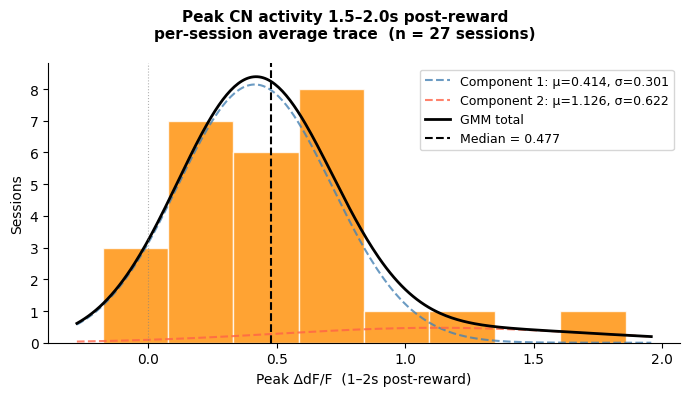


Saved → /results/figures/qc_postreward_hist.png

GMM components:
  Component 1: μ=0.4142  σ=0.3006  weight=0.893
  Component 2: μ=1.1264  σ=0.6222  weight=0.107

BIC = 39.8  (lower = better fit)
Peak values per session:
  849680  2026-06-22: +0.3220
  849680  2026-06-23: +0.3787
  849680  2026-06-24: +0.7363
  857094  2026-06-02: +0.6393
  857094  2026-06-03: +0.4775
  857094  2026-06-04: +0.7196
  857094  2026-06-05: +0.6504
  857094  2026-06-09: +1.8577
  857094  2026-06-10: +0.6775
  857094  2026-06-11: +0.5327
  857094  2026-06-15: +0.2684
  857094  2026-06-16: +0.0827
  857094  2026-06-17: +0.3388
  857094  2026-06-18: +0.7970
  857094  2026-06-22: +0.2978
  857094  2026-06-24: +0.2836
  857095  2026-06-01: +0.7004
  857095  2026-06-03: +1.1847
  857095  2026-06-04: +0.5373
  857095  2026-06-05: +0.8528
  857095  2026-06-09: +0.6071
  857095  2026-06-10: -0.1777
  857095  2026-06-11: +0.1098
  857095  2026-06-15: -0.1784
  857095  2026-06-16: +0.4238
  857095  2026-06-17: +0.0834

In [ ]:
# ── Histogram: peak CN activity 1–2s post-reward across sessions ──────────────
POST_WIN_START = 1.5   # seconds post-reward
POST_WIN_END   = 2.0   # seconds post-reward

peak_vals  = []
peak_labels = []

for s in session_records:
    pt = s['peri_trace']
    if pt is None:
        continue
    n       = len(pt)
    t_ax    = np.linspace(PLOT_SEC[0], PLOT_SEC[1], n)
    win_mask = (t_ax >= POST_WIN_START) & (t_ax <= POST_WIN_END)
    if not win_mask.any():
        print(f"  {s['label']}: window not found in trace — check PLOT_SEC")
        continue
    peak_vals.append(float(np.nanmax(pt[win_mask])))
    peak_labels.append(s['label'])

peak_vals = np.array(peak_vals)

fig5, ax5 = plt.subplots(figsize=(7, 4))
fig5.suptitle(f'Peak CN activity {POST_WIN_START}–{POST_WIN_END}s post-reward\n'
              f'per-session average trace  (n = {len(peak_vals)} sessions)',
              fontsize=11, fontweight='bold')

ax5.hist(peak_vals, bins='auto', color='darkorange', alpha=0.8, edgecolor='white')
from sklearn.mixture import GaussianMixture

# Fit 2-component Gaussian mixture
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(peak_vals.reshape(-1, 1))

# Sort components by mean so component 0 is always the left peak
order  = np.argsort(gmm.means_.ravel())
means  = gmm.means_.ravel()[order]
stds   = np.sqrt(gmm.covariances_.ravel())[order]
weights = gmm.weights_[order]

# Evaluate mixture PDF on a fine grid, scaled to histogram counts
x_fit  = np.linspace(peak_vals.min() - 0.1, peak_vals.max() + 0.1, 300)
bin_width = np.diff(ax5.patches[0].get_bbox().intervalx)[0]  # actual bin width
scale  = len(peak_vals) * bin_width   # scale PDF to match histogram counts

pdf_total = np.zeros_like(x_fit)
colors_gmm = ['steelblue', 'tomato']
for k in range(2):
    from scipy.stats import norm
    pdf_k = weights[k] * norm.pdf(x_fit, means[k], stds[k])
    ax5.plot(x_fit, pdf_k * scale, color=colors_gmm[k], lw=1.5, ls='--',
             alpha=0.8, label=f'Component {k+1}: μ={means[k]:.3f}, σ={stds[k]:.3f}')
    pdf_total += pdf_k

ax5.plot(x_fit, pdf_total * scale, color='k', lw=2.0,
         label='GMM total')
ax5.legend(fontsize=8)

ax5.axvline(np.median(peak_vals), color='k', lw=1.5, ls='--',
            label=f'Median = {np.median(peak_vals):.3f}')
ax5.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.6)

ax5.set_xlabel('Peak ΔdF/F  (1–2s post-reward)')
ax5.set_ylabel('Sessions')
ax5.legend(fontsize=9)
ax5.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out5 = Path("/results/figures/qc_postreward_hist.png")
out5.parent.mkdir(parents=True, exist_ok=True)
fig5.savefig(out5, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved → {out5}")
print(f"\nGMM components:")
for k in range(2):
    print(f"  Component {k+1}: μ={means[k]:.4f}  σ={stds[k]:.4f}  "
          f"weight={weights[k]:.3f}")
print(f"\nBIC = {gmm.bic(peak_vals.reshape(-1,1)):.1f}  "
      f"(lower = better fit)")
print(f"Peak values per session:")
for lbl, v in zip(peak_labels, peak_vals):
    print(f"  {lbl}: {v:+.4f}")
print(f"\nMean:   {np.mean(peak_vals):+.4f}")
print(f"Median: {np.median(peak_vals):+.4f}")
print(f"Std:    {np.std(peak_vals, ddof=1):.4f}")

<ipython-input-56-05b4bdf3353c>:36: RuntimeWarning: Mean of empty slice
  F0 = float(np.nanmean(F_cn_s[bs:be, i_tr]))
<ipython-input-56-05b4bdf3353c>:46: RuntimeWarning: All-NaN slice encountered
  trial_peaks.append(float(np.nanmax(seg)))


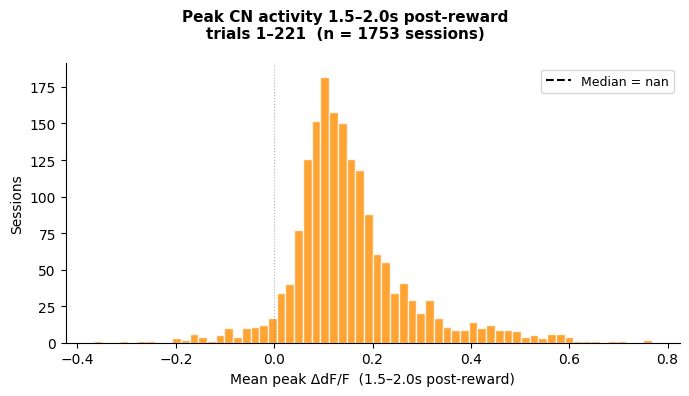


Peak values per session:
  849680  2026-06-22: +0.1813
  849680  2026-06-22: +0.2241
  849680  2026-06-22: +0.2043
  849680  2026-06-22: +0.1200
  849680  2026-06-22: +0.1164
  849680  2026-06-22: +0.0961
  849680  2026-06-22: +0.1373
  849680  2026-06-22: +0.1591
  849680  2026-06-22: +0.1342
  849680  2026-06-22: +0.1787
  849680  2026-06-22: +0.2973
  849680  2026-06-22: +0.1877
  849680  2026-06-22: +0.2001
  849680  2026-06-22: +0.1238
  849680  2026-06-22: +0.1245
  849680  2026-06-22: +0.2998
  849680  2026-06-22: +0.2011
  849680  2026-06-22: +0.1752
  849680  2026-06-22: +0.2040
  849680  2026-06-22: +0.2781
  849680  2026-06-22: +0.1670
  849680  2026-06-22: +0.3032
  849680  2026-06-22: +0.2107
  849680  2026-06-22: +0.1034
  849680  2026-06-22: +0.2822
  849680  2026-06-22: +0.1717
  849680  2026-06-22: +0.0635
  849680  2026-06-22: +0.0722
  849680  2026-06-22: +0.1530
  849680  2026-06-22: +0.1621
  849680  2026-06-22: +0.0905
  849680  2026-06-22: +0.2086
  849680  2026

In [56]:
# ── Histogram: peak CN activity 1–2s post-reward, trials 11–60 ────────────────
POST_WIN_START = 1.5
POST_WIN_END   = 2.0
TRIAL_START    = 0    # 0-indexed, so trial 11
TRIAL_END      = max(s['F_norm_cn'].shape[1] for s in session_records)    # inclusive

peak_vals   = []
peak_labels = []

for s in session_records:
    F_cn_s = s['F_norm_cn']          # (700, n_trials)
    rt_s   = s['rew_trial_sec']      # (n_trials,) seconds within trial
    n_t    = F_cn_s.shape[0]
    hp     = int(POST_WIN_START * s['fs'])
    hq     = int(POST_WIN_END   * s['fs'])
    bl_s   = int(abs(BASELINE_SEC[0]) * s['fs'])   # baseline start offset
    bl_e   = int(abs(BASELINE_SEC[1]) * s['fs'])   # baseline end offset

    # Restrict to trial window
    n_trials   = F_cn_s.shape[1]
    trial_mask = np.arange(n_trials)
    trial_mask = trial_mask[(trial_mask >= TRIAL_START) &
                            (trial_mask <  TRIAL_END)]

    trial_peaks = []
    for i_tr in trial_mask:
        if np.isnan(rt_s[i_tr]):
            continue
        rf = int(rt_s[i_tr] / s['dt_si'])

        # Baseline window relative to reward
        bs = rf + int(BASELINE_SEC[0] * s['fs'])
        be = rf + int(BASELINE_SEC[1] * s['fs'])
        if bs < 0 or be > n_t:
            continue
        F0 = float(np.nanmean(F_cn_s[bs:be, i_tr]))

        # Post-reward window
        ws = rf + int(POST_WIN_START * s['fs'])
        we = rf + int(POST_WIN_END   * s['fs'])
        if ws < 0 or we > n_t:
            continue

        seg = F_cn_s[ws:we, i_tr] - F0   # baseline-subtract
        if len(seg) > 0:
            trial_peaks.append(float(np.nanmax(seg)))

    if trial_peaks:
        peak_vals.extend(trial_peaks)   # individual trial peaks, not session mean
        peak_labels.extend([s['label']] * len(trial_peaks))
    else:
        print(f"  {s['label']}: no valid trials in range {TRIAL_START+1}–{TRIAL_END}")

peak_vals = np.array(peak_vals)

fig6, ax6 = plt.subplots(figsize=(7, 4))
fig6.suptitle(f'Peak CN activity {POST_WIN_START}–{POST_WIN_END}s post-reward\n'
              f'trials {TRIAL_START+1}–{TRIAL_END}  (n = {len(peak_vals)} sessions)',
              fontsize=11, fontweight='bold')

ax6.hist(peak_vals, bins='auto', color='darkorange', alpha=0.8, edgecolor='white')
ax6.axvline(np.median(peak_vals), color='k', lw=1.5, ls='--',
            label=f'Median = {np.median(peak_vals):.3f}')
ax6.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.6)
ax6.set_xlabel(f'Mean peak ΔdF/F  ({POST_WIN_START}–{POST_WIN_END}s post-reward)')
ax6.set_ylabel('Sessions')
ax6.legend(fontsize=9)
ax6.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out6 = Path("/results/figures/qc_postreward_hist_trials.png")
out6.parent.mkdir(parents=True, exist_ok=True)
fig6.savefig(out6, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPeak values per session:")
for lbl, v in zip(peak_labels, peak_vals):
    print(f"  {lbl}: {v:+.4f}")
print(f"\nMean:   {np.mean(peak_vals):+.4f}")
print(f"Median: {np.median(peak_vals):+.4f}")
print(f"Std:    {np.std(peak_vals, ddof=1):.4f}")

<ipython-input-58-9ff27757cdad>:41: RuntimeWarning: Mean of empty slice
  F0 = float(np.nanmean(F_cn_s[bs:be, i_tr]))


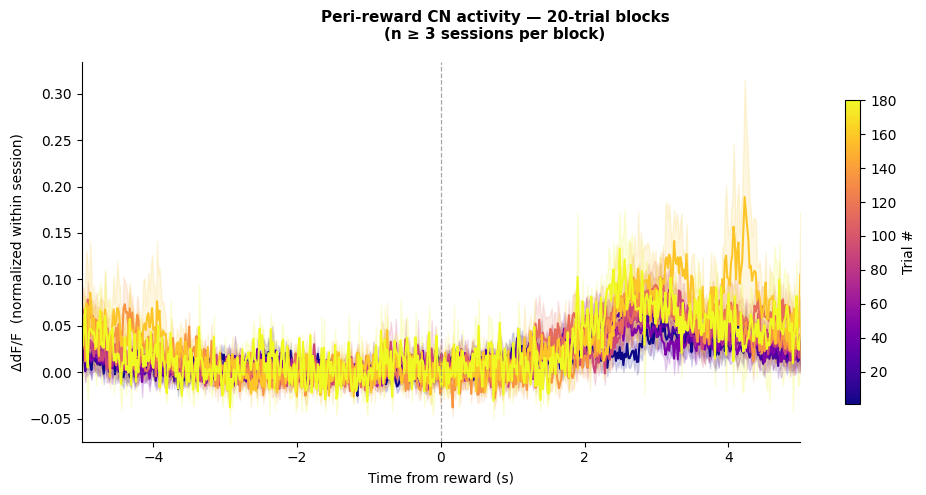

Saved → /results/figures/qc_peri_blocks.png
Plotted 9 blocks  |  skipped 3 blocks with < 3 sessions


In [ ]:
# ── Peri-reward traces split by 20-trial blocks ────────────────────────────────
BLOCK_SIZE        = 20
MIN_SESS_BLOCK    = 3
BASELINE_SEC_BLOCK = (-5., -4.)   # pre-reward baseline within trial window

fs_ref  = session_records[0]['fs']
hp_plot = int(abs(PLOT_SEC[0]) * fs_ref)
hq_plot = int(PLOT_SEC[1]     * fs_ref)
p_len   = hp_plot + hq_plot
t_ax    = np.linspace(PLOT_SEC[0], PLOT_SEC[1], p_len)

max_trials = max(s['F_norm_cn'].shape[1] for s in session_records)
n_blocks   = int(np.ceil(max_trials / BLOCK_SIZE))

# Per-block storage: each entry is a list of per-session mean traces
block_traces = [[] for _ in range(n_blocks)]

for s in session_records:
    F_cn_s   = s['F_norm_cn']
    rt_s     = s['rew_trial_sec']
    n_t      = F_cn_s.shape[0]
    n_trials = F_cn_s.shape[1]

    for b in range(n_blocks):
        t_s = b * BLOCK_SIZE
        t_e = min(t_s + BLOCK_SIZE, n_trials)
        if t_s >= n_trials:
            continue

        trials = []
        for i_tr in range(t_s, t_e):
            if np.isnan(rt_s[i_tr]):
                continue
            rf = int(rt_s[i_tr] / s['dt_si'])

            # Baseline
            bs = rf + int(BASELINE_SEC_BLOCK[0] * s['fs'])
            be = rf + int(BASELINE_SEC_BLOCK[1] * s['fs'])
            if bs < 0 or be > n_t:
                continue
            F0 = float(np.nanmean(F_cn_s[bs:be, i_tr]))

            # Plot window
            ws = rf + int(PLOT_SEC[0] * s['fs'])
            we = rf + int(PLOT_SEC[1] * s['fs'])
            if ws < 0 or we > n_t:
                continue
            seg = F_cn_s[ws:we, i_tr] - F0
            if len(seg) == p_len:
                trials.append(seg)

        if trials:
            block_traces[b].append(np.nanmean(trials, axis=0))

# ── Pool across sessions per block ────────────────────────────────────────────
valid_blocks = [(b, block_traces[b]) for b in range(n_blocks)
                if len(block_traces[b]) >= MIN_SESS_BLOCK]

n_valid = len(valid_blocks)
cmap    = plt.cm.plasma
colors  = [cmap(i / max(n_valid - 1, 1)) for i in range(n_valid)]

fig7, ax7 = plt.subplots(figsize=(10, 5))
fig7.suptitle(f'Peri-reward CN activity — {BLOCK_SIZE}-trial blocks\n'
              f'(n ≥ {MIN_SESS_BLOCK} sessions per block)',
              fontsize=11, fontweight='bold')

for idx, (b, traces) in enumerate(valid_blocks):
    col      = colors[idx]
    mat      = np.vstack(traces)
    mu       = np.nanmean(mat, axis=0)
    sem      = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(mat.shape[0])
    t_label  = f'Trials {b*BLOCK_SIZE+1}–{b*BLOCK_SIZE+BLOCK_SIZE}'
    ax7.fill_between(t_ax, mu - sem, mu + sem,
                     alpha=0.15, color=col)
    ax7.plot(t_ax, mu, color=col, lw=1.5, label=t_label)

ax7.axvline(0, color='gray', ls='--', lw=0.9, alpha=0.7)
ax7.axhline(0, color='gray', ls='-',  lw=0.4, alpha=0.4)

# Colorbar as legend proxy (early → late)
sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(1, n_valid * BLOCK_SIZE))
sm.set_array([])
fig7.colorbar(sm, ax=ax7, label='Trial #', shrink=0.8)

ax7.set_xlabel('Time from reward (s)')
ax7.set_ylabel('ΔdF/F  (normalized within session)')
ax7.set_xlim(PLOT_SEC)
ax7.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out7 = Path("/results/figures/qc_peri_blocks.png")
out7.parent.mkdir(parents=True, exist_ok=True)
fig7.savefig(out7, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out7}")
print(f"Plotted {n_valid} blocks  |  "
      f"skipped {n_blocks - n_valid} blocks with < {MIN_SESS_BLOCK} sessions")